In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

data_path = Path("/content/drive/MyDrive/Weather_Data_Analysis/archive")

print("Folder exists:", data_path.exists())

if data_path.exists():
    print("\nFiles found:")
    for file in data_path.iterdir():
        print(file.name)

Folder exists: True

Files found:
delhi.csv
bengaluru.csv
bombay.csv
hyderabad.csv
jaipur.csv
nagpur.csv
pune.csv
kanpur.csv


In [ ]:
import pandas as pd
import numpy as np

csv_files = sorted(data_path.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files\n")

data = {}

for file in csv_files:
    city = file.stem.title()
    df = pd.read_csv(file)
    data[city] = df

    print(f"{city:<12} → {df.shape[0]:,} rows × {df.shape[1]} columns")

Found 8 CSV files

Bengaluru    → 96,432 rows × 25 columns
Bombay       → 96,432 rows × 25 columns
Delhi        → 96,432 rows × 25 columns
Hyderabad    → 96,432 rows × 25 columns
Jaipur       → 96,432 rows × 25 columns
Kanpur       → 96,432 rows × 25 columns
Nagpur       → 96,432 rows × 25 columns
Pune         → 96,432 rows × 25 columns


In [ ]:
weather_data = []

for city, df in data.items():
    df = df.copy()
    df["City"] = city
    weather_data.append(df)

weather_df = pd.concat(weather_data, ignore_index=True)

print("Combined Dataset")
print("=" * 40)
print(f"Rows    : {weather_df.shape[0]:,}")
print(f"Columns : {weather_df.shape[1]}")

Combined Dataset
Rows    : 771,456
Columns : 26


In [ ]:
weather_df.head()

,date_time,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,...,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,City
0,2009-01-01 00:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,11,2,91,0.0,1014,14,10,109,8,Bengaluru
1,2009-01-01 01:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,9,2,93,0.0,1014,14,7,85,6,Bengaluru
2,2009-01-01 02:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,7,2,94,0.0,1014,13,5,61,4,Bengaluru
3,2009-01-01 03:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,5,2,96,0.0,1014,12,2,37,3,Bengaluru
4,2009-01-01 04:00:00,27,12,0.0,11.6,5,1,31,09:58 AM,10:03 PM,...,5,1,88,0.0,1015,14,5,45,3,Bengaluru


In [ ]:
weather_df["City"].value_counts()

,count
City,
Bengaluru,96432
Bombay,96432
Delhi,96432
Hyderabad,96432
Jaipur,96432
Kanpur,96432
Nagpur,96432
Pune,96432


In [ ]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771456 entries, 0 to 771455
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date_time          771456 non-null  object 
 1   maxtempC           771456 non-null  int64  
 2   mintempC           771456 non-null  int64  
 3   totalSnow_cm       771456 non-null  float64
 4   sunHour            771456 non-null  float64
 5   uvIndex            771456 non-null  int64  
 6   uvIndex.1          771456 non-null  int64  
 7   moon_illumination  771456 non-null  int64  
 8   moonrise           771456 non-null  object 
 9   moonset            771456 non-null  object 
 10  sunrise            771456 non-null  object 
 11  sunset             771456 non-null  object 
 12  DewPointC          771456 non-null  int64  
 13  FeelsLikeC         771456 non-null  int64  
 14  HeatIndexC         771456 non-null  int64  
 15  WindChillC         771456 non-null  int64  
 16  Wi

In [ ]:
print("Rows:", f"{weather_df.shape[0]:,}")
print("Columns:", weather_df.shape[1])

Rows: 771,456
Columns: 26


In [ ]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771456 entries, 0 to 771455
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date_time          771456 non-null  object 
 1   maxtempC           771456 non-null  int64  
 2   mintempC           771456 non-null  int64  
 3   totalSnow_cm       771456 non-null  float64
 4   sunHour            771456 non-null  float64
 5   uvIndex            771456 non-null  int64  
 6   uvIndex.1          771456 non-null  int64  
 7   moon_illumination  771456 non-null  int64  
 8   moonrise           771456 non-null  object 
 9   moonset            771456 non-null  object 
 10  sunrise            771456 non-null  object 
 11  sunset             771456 non-null  object 
 12  DewPointC          771456 non-null  int64  
 13  FeelsLikeC         771456 non-null  int64  
 14  HeatIndexC         771456 non-null  int64  
 15  WindChillC         771456 non-null  int64  
 16  Wi

In [ ]:
missing = weather_df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(weather_df) * 100).round(2)
})

missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Missing %
date_time,0,0.0
maxtempC,0,0.0
mintempC,0,0.0
totalSnow_cm,0,0.0
sunHour,0,0.0
uvIndex,0,0.0
uvIndex.1,0,0.0
moon_illumination,0,0.0
moonrise,0,0.0
moonset,0,0.0


In [ ]:
duplicate_count = weather_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
print("Number of cities:", weather_df["City"].nunique())
print("\nCities:")
print(weather_df["City"].unique())

Number of cities: 8

Cities:
['Bengaluru' 'Bombay' 'Delhi' 'Hyderabad' 'Jaipur' 'Kanpur' 'Nagpur'
 'Pune']


In [ ]:
weather_df["City"].value_counts()

,count
City,
Bengaluru,96432
Bombay,96432
Delhi,96432
Hyderabad,96432
Jaipur,96432
Kanpur,96432
Nagpur,96432
Pune,96432


In [ ]:
print("Data type:", weather_df["date_time"].dtype)

print("\nFirst dates:")
print(weather_df["date_time"].head())

print("\nLast dates:")
print(weather_df["date_time"].tail())

Data type: object

First dates:
0    2009-01-01 00:00:00
1    2009-01-01 01:00:00
2    2009-01-01 02:00:00
3    2009-01-01 03:00:00
4    2009-01-01 04:00:00
Name: date_time, dtype: object

Last dates:
771451    2020-01-01 19:00:00
771452    2020-01-01 20:00:00
771453    2020-01-01 21:00:00
771454    2020-01-01 22:00:00
771455    2020-01-01 23:00:00
Name: date_time, dtype: object


In [ ]:
print("Earliest:", weather_df["date_time"].min())
print("Latest:", weather_df["date_time"].max())

Earliest: 2009-01-01 00:00:00
Latest: 2020-01-01 23:00:00


In [ ]:
weather_df.describe().T

,count,mean,std,min,25%,50%,75%,max
maxtempC,771456.0,31.961237,5.575411,12.0,28.0,31.0,35.0,52.0
mintempC,771456.0,21.851201,5.880866,1.0,18.0,22.0,26.0,43.0
totalSnow_cm,771456.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
sunHour,771456.0,10.853609,2.004205,3.8,8.7,11.6,11.9,14.0
uvIndex,771456.0,6.578335,1.271368,3.0,6.0,6.0,7.0,11.0
uvIndex.1,771456.0,4.311927,3.213428,1.0,1.0,5.0,7.0,11.0
moon_illumination,771456.0,46.094077,31.249583,0.0,18.0,46.0,73.0,100.0
DewPointC,771456.0,14.492267,7.617042,-22.0,9.0,16.0,21.0,31.0
FeelsLikeC,771456.0,28.968461,7.436823,4.0,25.0,29.0,34.0,65.0
HeatIndexC,771456.0,29.128320,7.280620,5.0,25.0,29.0,34.0,65.0


In [ ]:
weather_df[
    [
        "maxtempC",
        "mintempC",
        "tempC",
        "humidity",
        "precipMM",
        "windspeedKmph",
        "WindGustKmph",
        "pressure",
        "visibility",
        "cloudcover",
        "uvIndex"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
maxtempC,771456.0,31.961237,5.575411,12.0,28.0,31.0,35.0,52.0
mintempC,771456.0,21.851201,5.880866,1.0,18.0,22.0,26.0,43.0
tempC,771456.0,26.463334,6.724919,0.0,22.0,26.0,31.0,51.0
humidity,771456.0,51.596677,24.475469,2.0,31.0,51.0,72.0,100.0
precipMM,771456.0,0.067854,0.400212,0.0,0.0,0.0,0.0,30.6
windspeedKmph,771456.0,10.622742,5.530310,0.0,7.0,10.0,13.0,47.0
WindGustKmph,771456.0,15.170196,7.871760,0.0,9.0,14.0,20.0,85.0
pressure,771456.0,1008.523362,5.837984,986.0,1005.0,1009.0,1013.0,1026.0
visibility,771456.0,9.713785,1.432286,0.0,10.0,10.0,10.0,20.0
cloudcover,771456.0,22.838899,27.250547,0.0,1.0,10.0,39.0,100.0


In [ ]:
print("DATA UNDERSTANDING COMPLETE")
print("=" * 50)
print(f"Total Records : {len(weather_df):,}")
print(f"Total Columns : {weather_df.shape[1]}")
print(f"Cities        : {weather_df['City'].nunique()}")
print(f"Duplicates    : {weather_df.duplicated().sum()}")
print(f"Missing Cells : {weather_df.isnull().sum().sum():,}")

DATA UNDERSTANDING COMPLETE
Total Records : 771,456
Total Columns : 26
Cities        : 8
Duplicates    : 0
Missing Cells : 0


In [ ]:
# Check columns of every city dataset

for city, df in data.items():
    print(f"\n{city}")
    print("-" * 40)
    print(list(df.columns))


Bengaluru
----------------------------------------
['date_time', 'maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour', 'uvIndex', 'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset', 'sunrise', 'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC', 'WindChillC', 'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure', 'tempC', 'visibility', 'winddirDegree', 'windspeedKmph']

Bombay
----------------------------------------
['date_time', 'maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour', 'uvIndex', 'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset', 'sunrise', 'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC', 'WindChillC', 'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure', 'tempC', 'visibility', 'winddirDegree', 'windspeedKmph']

Delhi
----------------------------------------
['date_time', 'maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour', 'uvIndex', 'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset', 'sunrise', 'sunset', 'DewPointC', 'FeelsLikeC', 'HeatI

In [ ]:
# Check whether all datasets have identical columns

reference_columns = list(data[list(data.keys())[0]].columns)

for city, df in data.items():
    if list(df.columns) == reference_columns:
        print(f"✓ {city}: Structure matches")
    else:
        print(f"✗ {city}: Structure is different")

✓ Bengaluru: Structure matches
✓ Bombay: Structure matches
✓ Delhi: Structure matches
✓ Hyderabad: Structure matches
✓ Jaipur: Structure matches
✓ Kanpur: Structure matches
✓ Nagpur: Structure matches
✓ Pune: Structure matches


In [ ]:
output_path = "/content/drive/MyDrive/Weather_Data_Analysis/weather_combined_raw.csv"

weather_df.to_csv(output_path, index=False)

print("Saved successfully:")
print(output_path)

Saved successfully:
/content/drive/MyDrive/Weather_Data_Analysis/weather_combined_raw.csv


In [ ]:
weather_clean = weather_df.copy()

print("Working dataset created.")
print("Shape:", weather_clean.shape)

Working dataset created.
Shape: (771456, 26)


In [ ]:
weather_clean["date_time"] = pd.to_datetime(
    weather_clean["date_time"],
    errors="coerce"
)

print(weather_clean["date_time"].dtype)

datetime64[ns]


In [ ]:
print("Invalid dates:", weather_clean["date_time"].isna().sum())

Invalid dates: 0


In [ ]:
missing = weather_clean.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(weather_clean) * 100).round(2)
})

missing_df = missing_df.sort_values(
    "Missing Values",
    ascending=False
)

display(missing_df)

,Missing Values,Missing %
date_time,0,0.0
maxtempC,0,0.0
mintempC,0,0.0
totalSnow_cm,0,0.0
sunHour,0,0.0
uvIndex,0,0.0
uvIndex.1,0,0.0
moon_illumination,0,0.0
moonrise,0,0.0
moonset,0,0.0


In [ ]:
numeric_columns = weather_clean.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour', 'uvIndex', 'uvIndex.1', 'moon_illumination', 'DewPointC', 'FeelsLikeC', 'HeatIndexC', 'WindChillC', 'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure', 'tempC', 'visibility', 'winddirDegree', 'windspeedKmph']


In [ ]:
weather_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
maxtempC,771456.0,31.961237,5.575411,12.0,28.0,31.0,35.0,52.0
mintempC,771456.0,21.851201,5.880866,1.0,18.0,22.0,26.0,43.0
totalSnow_cm,771456.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
sunHour,771456.0,10.853609,2.004205,3.8,8.7,11.6,11.9,14.0
uvIndex,771456.0,6.578335,1.271368,3.0,6.0,6.0,7.0,11.0
uvIndex.1,771456.0,4.311927,3.213428,1.0,1.0,5.0,7.0,11.0
moon_illumination,771456.0,46.094077,31.249583,0.0,18.0,46.0,73.0,100.0
DewPointC,771456.0,14.492267,7.617042,-22.0,9.0,16.0,21.0,31.0
FeelsLikeC,771456.0,28.968461,7.436823,4.0,25.0,29.0,34.0,65.0
HeatIndexC,771456.0,29.128320,7.280620,5.0,25.0,29.0,34.0,65.0


In [ ]:
cleaning_summary = {
    "Rows": len(weather_clean),
    "Columns": weather_clean.shape[1],
    "Duplicate Rows": weather_clean.duplicated().sum(),
    "Missing Cells": weather_clean.isnull().sum().sum(),
    "Invalid Dates": weather_clean["date_time"].isna().sum(),
    "Cities": weather_clean["City"].nunique()
}

cleaning_summary

{'Rows': 771456,
 'Columns': 26,
 'Duplicate Rows': np.int64(0),
 'Missing Cells': np.int64(0),
 'Invalid Dates': np.int64(0),
 'Cities': 8}

In [ ]:
# Final validation of important weather variables

checks = {}

# Temperature consistency
checks["Max temp < Min temp"] = (
    weather_clean["maxtempC"] < weather_clean["mintempC"]
).sum()

# Humidity
checks["Humidity < 0"] = (
    weather_clean["humidity"] < 0
).sum()

checks["Humidity > 100"] = (
    weather_clean["humidity"] > 100
).sum()

# Wind direction
checks["Wind direction < 0"] = (
    weather_clean["winddirDegree"] < 0
).sum()

checks["Wind direction > 360"] = (
    weather_clean["winddirDegree"] > 360
).sum()

# Rainfall
checks["Negative rainfall"] = (
    weather_clean["precipMM"] < 0
).sum()

# Other non-negative variables
for col in [
    "windspeedKmph",
    "WindGustKmph",
    "visibility",
    "cloudcover",
    "uvIndex"
]:
    checks[f"Negative {col}"] = (
        weather_clean[col] < 0
    ).sum()

for check, count in checks.items():
    print(f"{check:<35}: {count}")

Max temp < Min temp                : 0
Humidity < 0                       : 0
Humidity > 100                     : 0
Wind direction < 0                 : 0
Wind direction > 360               : 0
Negative rainfall                  : 0
Negative windspeedKmph             : 0
Negative WindGustKmph              : 0
Negative visibility                : 0
Negative cloudcover                : 0
Negative uvIndex                   : 0


In [ ]:
weather_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
date_time,771456,2014-07-02 23:30:00.000002560,2009-01-01 00:00:00,2011-10-02 11:45:00,2014-07-02 23:30:00,2017-04-02 11:15:00,2020-01-01 23:00:00,NaN
maxtempC,771456.0,31.961237,12.0,28.0,31.0,35.0,52.0,5.575411
mintempC,771456.0,21.851201,1.0,18.0,22.0,26.0,43.0,5.880866
totalSnow_cm,771456.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sunHour,771456.0,10.853609,3.8,8.7,11.6,11.9,14.0,2.004205
uvIndex,771456.0,6.578335,3.0,6.0,6.0,7.0,11.0,1.271368
uvIndex.1,771456.0,4.311927,1.0,1.0,5.0,7.0,11.0,3.213428
moon_illumination,771456.0,46.094077,0.0,18.0,46.0,73.0,100.0,31.249583
DewPointC,771456.0,14.492267,-22.0,9.0,16.0,21.0,31.0,7.617042
FeelsLikeC,771456.0,28.968461,4.0,25.0,29.0,34.0,65.0,7.436823


In [ ]:
# Check logical consistency between temperature variables

temperature_issues = {
    "Max temp < Min temp": (
        weather_clean["maxtempC"] < weather_clean["mintempC"]
    ).sum(),

    "Humidity < 0": (
        weather_clean["humidity"] < 0
    ).sum(),

    "Humidity > 100": (
        weather_clean["humidity"] > 100
    ).sum(),

    "Wind direction < 0": (
        weather_clean["winddirDegree"] < 0
    ).sum(),

    "Wind direction > 360": (
        weather_clean["winddirDegree"] > 360
    ).sum(),

    "Negative rainfall": (
        weather_clean["precipMM"] < 0
    ).sum(),

    "Negative wind speed": (
        weather_clean["windspeedKmph"] < 0
    ).sum(),

    "Negative wind gust": (
        weather_clean["WindGustKmph"] < 0
    ).sum(),

    "Negative cloud cover": (
        weather_clean["cloudcover"] < 0
    ).sum(),

    "Cloud cover > 100": (
        weather_clean["cloudcover"] > 100
    ).sum(),

    "Negative UV index": (
        weather_clean["uvIndex"] < 0
    ).sum()
}

for check, count in temperature_issues.items():
    print(f"{check:<30}: {count}")

Max temp < Min temp           : 0
Humidity < 0                  : 0
Humidity > 100                : 0
Wind direction < 0            : 0
Wind direction > 360          : 0
Negative rainfall             : 0
Negative wind speed           : 0
Negative wind gust            : 0
Negative cloud cover          : 0
Cloud cover > 100             : 0
Negative UV index             : 0


In [ ]:
extreme_temp = weather_clean[
    (weather_clean["maxtempC"] > 45) |
    (weather_clean["tempC"] > 45) |
    (weather_clean["FeelsLikeC"] > 50) |
    (weather_clean["HeatIndexC"] > 50)
]

print("Extreme temperature records:", len(extreme_temp))

display(
    extreme_temp[
        [
            "date_time",
            "City",
            "maxtempC",
            "mintempC",
            "tempC",
            "FeelsLikeC",
            "HeatIndexC",
            "WindChillC",
            "humidity"
        ]
    ].head(20)
)

Extreme temperature records: 9512


,date_time,City,maxtempC,mintempC,tempC,FeelsLikeC,HeatIndexC,WindChillC,humidity
98817,2009-04-10 09:00:00,Bombay,35,27,35,51,51,41,41
99201,2009-04-26 09:00:00,Bombay,35,27,35,52,52,40,44
99224,2009-04-27 08:00:00,Bombay,34,28,33,52,52,38,55
99225,2009-04-27 09:00:00,Bombay,34,28,34,55,55,40,51
99342,2009-05-02 06:00:00,Bombay,33,26,29,51,51,35,70
99366,2009-05-03 06:00:00,Bombay,33,26,30,51,51,36,66
99390,2009-05-04 06:00:00,Bombay,33,26,30,51,51,36,67
99438,2009-05-06 06:00:00,Bombay,32,26,30,51,51,36,69
107961,2010-04-26 09:00:00,Bombay,34,27,34,55,55,39,53
107982,2010-04-27 06:00:00,Bombay,34,27,31,51,51,37,62


In [ ]:
# ============================================================
# STEP 5 — FINAL DATA QUALITY & VALIDATION TESTS
# ============================================================

print("=" * 70)
print("           WEATHER DATA — FINAL QUALITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. BASIC DATASET CHECK
# ------------------------------------------------------------

print("\n[1] BASIC DATASET")
print("-" * 50)

print(f"Total Rows       : {len(weather_clean):,}")
print(f"Total Columns    : {weather_clean.shape[1]}")
print(f"Number of Cities : {weather_clean['City'].nunique()}")
print(f"Missing Cells    : {weather_clean.isnull().sum().sum():,}")
print(f"Duplicate Rows   : {weather_clean.duplicated().sum():,}")


# ------------------------------------------------------------
# 2. DATE VALIDATION
# ------------------------------------------------------------

print("\n[2] DATE VALIDATION")
print("-" * 50)

invalid_dates = weather_clean["date_time"].isna().sum()

print(f"Invalid Dates    : {invalid_dates:,}")
print(f"Start Date       : {weather_clean['date_time'].min()}")
print(f"End Date         : {weather_clean['date_time'].max()}")


# ------------------------------------------------------------
# 3. TEMPERATURE LOGICAL CHECK
# ------------------------------------------------------------

print("\n[3] TEMPERATURE VALIDATION")
print("-" * 50)

max_less_than_min = (
    weather_clean["maxtempC"] < weather_clean["mintempC"]
).sum()

actual_temp_above_45 = (
    weather_clean["tempC"] > 45
).sum()

actual_temp_below_minus_10 = (
    weather_clean["tempC"] < -10
).sum()

print(f"Max Temp < Min Temp       : {max_less_than_min:,}")
print(f"Actual Temp > 45°C        : {actual_temp_above_45:,}")
print(f"Actual Temp < -10°C       : {actual_temp_below_minus_10:,}")
print(f"Maximum Actual Temp       : {weather_clean['tempC'].max()}°C")
print(f"Minimum Actual Temp       : {weather_clean['tempC'].min()}°C")


# ------------------------------------------------------------
# 4. HUMIDITY VALIDATION
# ------------------------------------------------------------

print("\n[4] HUMIDITY VALIDATION")
print("-" * 50)

humidity_below_0 = (
    weather_clean["humidity"] < 0
).sum()

humidity_above_100 = (
    weather_clean["humidity"] > 100
).sum()

print(f"Humidity < 0%     : {humidity_below_0:,}")
print(f"Humidity > 100%   : {humidity_above_100:,}")
print(f"Minimum Humidity  : {weather_clean['humidity'].min()}%")
print(f"Maximum Humidity  : {weather_clean['humidity'].max()}%")


# ------------------------------------------------------------
# 5. RAINFALL VALIDATION
# ------------------------------------------------------------

print("\n[5] RAINFALL VALIDATION")
print("-" * 50)

negative_rainfall = (
    weather_clean["precipMM"] < 0
).sum()

print(f"Negative Rainfall : {negative_rainfall:,}")
print(f"Maximum Rainfall  : {weather_clean['precipMM'].max()} mm")


# ------------------------------------------------------------
# 6. WIND VALIDATION
# ------------------------------------------------------------

print("\n[6] WIND VALIDATION")
print("-" * 50)

negative_wind_speed = (
    weather_clean["windspeedKmph"] < 0
).sum()

negative_wind_gust = (
    weather_clean["WindGustKmph"] < 0
).sum()

invalid_wind_direction = (
    (weather_clean["winddirDegree"] < 0) |
    (weather_clean["winddirDegree"] > 360)
).sum()

print(f"Negative Wind Speed       : {negative_wind_speed:,}")
print(f"Negative Wind Gust        : {negative_wind_gust:,}")
print(f"Invalid Wind Direction    : {invalid_wind_direction:,}")
print(f"Maximum Wind Speed        : {weather_clean['windspeedKmph'].max()} km/h")
print(f"Maximum Wind Gust         : {weather_clean['WindGustKmph'].max()} km/h")


# ------------------------------------------------------------
# 7. OTHER WEATHER VARIABLE VALIDATION
# ------------------------------------------------------------

print("\n[7] OTHER WEATHER VARIABLES")
print("-" * 50)

checks = {
    "Cloud Cover < 0": (weather_clean["cloudcover"] < 0).sum(),
    "Cloud Cover > 100": (weather_clean["cloudcover"] > 100).sum(),
    "Visibility < 0": (weather_clean["visibility"] < 0).sum(),
    "UV Index < 0": (weather_clean["uvIndex"] < 0).sum(),
    "Pressure < 0": (weather_clean["pressure"] < 0).sum(),
    "Sun Hour < 0": (weather_clean["sunHour"] < 0).sum(),
    "Moon Illumination < 0": (weather_clean["moon_illumination"] < 0).sum(),
    "Moon Illumination > 100": (weather_clean["moon_illumination"] > 100).sum(),
}

for check, count in checks.items():
    print(f"{check:<30}: {count:,}")


# ------------------------------------------------------------
# 8. CONSTANT COLUMNS
# ------------------------------------------------------------

print("\n[8] CONSTANT COLUMNS")
print("-" * 50)

constant_columns = [
    col for col in weather_clean.columns
    if weather_clean[col].nunique() <= 1
]

if constant_columns:
    print("Columns with no variation:")
    for col in constant_columns:
        print(f"  • {col}")
else:
    print("No constant columns found.")


# ------------------------------------------------------------
# 9. CITY DISTRIBUTION
# ------------------------------------------------------------

print("\n[9] CITY DISTRIBUTION")
print("-" * 50)

city_counts = weather_clean["City"].value_counts()

print(city_counts.to_string())


# ------------------------------------------------------------
# 10. EXTREME APPARENT / HEAT INDEX VALUES
# ------------------------------------------------------------

print("\n[10] EXTREME APPARENT TEMPERATURE")
print("-" * 50)

extreme_apparent = (
    (weather_clean["FeelsLikeC"] > 50) |
    (weather_clean["HeatIndexC"] > 50)
).sum()

print(f"Records with FeelsLike/HeatIndex > 50°C: {extreme_apparent:,}")


# ------------------------------------------------------------
# 11. ACTUAL TEMPERATURE EXTREMES BY CITY
# ------------------------------------------------------------

print("\n[11] ACTUAL TEMPERATURE > 45°C BY CITY")
print("-" * 50)

actual_extreme = weather_clean[
    weather_clean["tempC"] > 45
]

if len(actual_extreme) > 0:
    print(actual_extreme["City"].value_counts().to_string())
else:
    print("No records found.")


# ------------------------------------------------------------
# 12. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATA QUALITY STATUS")
print("=" * 70)

total_missing = weather_clean.isnull().sum().sum()
total_duplicates = weather_clean.duplicated().sum()

logical_issues = (
    max_less_than_min +
    humidity_below_0 +
    humidity_above_100 +
    negative_rainfall +
    negative_wind_speed +
    negative_wind_gust +
    invalid_wind_direction
)

print(f"Missing Values       : {total_missing:,}")
print(f"Duplicate Rows       : {total_duplicates:,}")
print(f"Logical Issues       : {logical_issues:,}")

if total_missing == 0 and total_duplicates == 0 and logical_issues == 0:
    print("\n✓ BASIC DATA QUALITY CHECKS PASSED")
else:
    print("\n⚠ DATA QUALITY ISSUES REQUIRE REVIEW")

print("=" * 70)

           WEATHER DATA — FINAL QUALITY CHECK

[1] BASIC DATASET
--------------------------------------------------
Total Rows       : 771,456
Total Columns    : 26
Number of Cities : 8
Missing Cells    : 0
Duplicate Rows   : 0

[2] DATE VALIDATION
--------------------------------------------------
Invalid Dates    : 0
Start Date       : 2009-01-01 00:00:00
End Date         : 2020-01-01 23:00:00

[3] TEMPERATURE VALIDATION
--------------------------------------------------
Max Temp < Min Temp       : 0
Actual Temp > 45°C        : 1,303
Actual Temp < -10°C       : 0
Maximum Actual Temp       : 51°C
Minimum Actual Temp       : 0°C

[4] HUMIDITY VALIDATION
--------------------------------------------------
Humidity < 0%     : 0
Humidity > 100%   : 0
Minimum Humidity  : 2%
Maximum Humidity  : 100%

[5] RAINFALL VALIDATION
--------------------------------------------------
Negative Rainfall : 0
Maximum Rainfall  : 30.6 mm

[6] WIND VALIDATION
------------------------------------------------

In [ ]:
# ============================================================
# STEP 6 — FEATURE ENGINEERING
# ============================================================

# Make sure date_time is datetime
weather_clean["date_time"] = pd.to_datetime(
    weather_clean["date_time"],
    errors="coerce"
)

# ------------------------------------------------------------
# TIME FEATURES
# ------------------------------------------------------------

weather_clean["Year"] = weather_clean["date_time"].dt.year
weather_clean["Month"] = weather_clean["date_time"].dt.month
weather_clean["Month_Name"] = weather_clean["date_time"].dt.month_name()
weather_clean["Day"] = weather_clean["date_time"].dt.day
weather_clean["Hour"] = weather_clean["date_time"].dt.hour
weather_clean["Day_of_Week"] = weather_clean["date_time"].dt.day_name()

# ------------------------------------------------------------
# SEASON
# ------------------------------------------------------------

def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

weather_clean["Season"] = weather_clean["Month"].apply(assign_season)

# ------------------------------------------------------------
# TEMPERATURE FEATURES
# ------------------------------------------------------------

weather_clean["Temperature_Range"] = (
    weather_clean["maxtempC"] -
    weather_clean["mintempC"]
)

# ------------------------------------------------------------
# RAINFALL CATEGORY
# ------------------------------------------------------------

def rainfall_category(value):
    if value == 0:
        return "No Rain"
    elif value <= 2.5:
        return "Light Rain"
    elif value <= 15:
        return "Moderate Rain"
    elif value <= 64.5:
        return "Heavy Rain"
    else:
        return "Very Heavy Rain"

weather_clean["Rainfall_Category"] = (
    weather_clean["precipMM"].apply(rainfall_category)
)

# ------------------------------------------------------------
# HUMIDITY CATEGORY
# ------------------------------------------------------------

def humidity_category(value):
    if value < 30:
        return "Low"
    elif value < 60:
        return "Moderate"
    elif value < 80:
        return "High"
    else:
        return "Very High"

weather_clean["Humidity_Category"] = (
    weather_clean["humidity"].apply(humidity_category)
)

# ------------------------------------------------------------
# WIND SPEED CATEGORY
# ------------------------------------------------------------

def wind_category(value):
    if value < 5:
        return "Calm"
    elif value < 15:
        return "Moderate"
    elif value < 25:
        return "Strong"
    else:
        return "Very Strong"

weather_clean["Wind_Speed_Category"] = (
    weather_clean["windspeedKmph"].apply(wind_category)
)

# ------------------------------------------------------------
# RAINY DAY FLAG
# ------------------------------------------------------------

weather_clean["Rainy_Day"] = (
    weather_clean["precipMM"] > 0
).astype(int)

# ------------------------------------------------------------
# EXTREME HEAT FLAG
# ------------------------------------------------------------

weather_clean["Extreme_Heat"] = (
    weather_clean["tempC"] > 45
).astype(int)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 70)

print(f"Rows    : {weather_clean.shape[0]:,}")
print(f"Columns : {weather_clean.shape[1]}")

print("\nNew Features:")
new_features = [
    "Year",
    "Month",
    "Month_Name",
    "Day",
    "Hour",
    "Day_of_Week",
    "Season",
    "Temperature_Range",
    "Rainfall_Category",
    "Humidity_Category",
    "Wind_Speed_Category",
    "Rainy_Day",
    "Extreme_Heat"
]

for feature in new_features:
    print(f"  ✓ {feature}")

FEATURE ENGINEERING COMPLETED
Rows    : 771,456
Columns : 39

New Features:
  ✓ Year
  ✓ Month
  ✓ Month_Name
  ✓ Day
  ✓ Hour
  ✓ Day_of_Week
  ✓ Season
  ✓ Temperature_Range
  ✓ Rainfall_Category
  ✓ Humidity_Category
  ✓ Wind_Speed_Category
  ✓ Rainy_Day
  ✓ Extreme_Heat


In [ ]:
# ============================================================
# STEP 6.1 — FEATURE ENGINEERING VALIDATION
# ============================================================

print("=" * 70)
print("       FEATURE ENGINEERING — VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK NEW COLUMNS
# ------------------------------------------------------------

new_features = [
    "Year",
    "Month",
    "Month_Name",
    "Day",
    "Hour",
    "Day_of_Week",
    "Season",
    "Temperature_Range",
    "Rainfall_Category",
    "Humidity_Category",
    "Wind_Speed_Category",
    "Rainy_Day",
    "Extreme_Heat"
]

print("\n[1] NEW FEATURES")
print("-" * 50)

for feature in new_features:
    exists = feature in weather_clean.columns
    print(f"{feature:<25}: {'✓ Present' if exists else '✗ Missing'}")


# ------------------------------------------------------------
# 2. CHECK TIME FEATURES
# ------------------------------------------------------------

print("\n[2] TIME FEATURES")
print("-" * 50)

print("Years:")
print(sorted(weather_clean["Year"].unique()))

print("\nMonths:")
print(sorted(weather_clean["Month"].unique()))

print("\nHours:")
print(sorted(weather_clean["Hour"].unique()))


# ------------------------------------------------------------
# 3. CHECK SEASONS
# ------------------------------------------------------------

print("\n[3] SEASON DISTRIBUTION")
print("-" * 50)

print(weather_clean["Season"].value_counts())


# ------------------------------------------------------------
# 4. CHECK RAINFALL CATEGORIES
# ------------------------------------------------------------

print("\n[4] RAINFALL CATEGORIES")
print("-" * 50)

print(weather_clean["Rainfall_Category"].value_counts())


# ------------------------------------------------------------
# 5. CHECK HUMIDITY CATEGORIES
# ------------------------------------------------------------

print("\n[5] HUMIDITY CATEGORIES")
print("-" * 50)

print(weather_clean["Humidity_Category"].value_counts())


# ------------------------------------------------------------
# 6. CHECK WIND CATEGORIES
# ------------------------------------------------------------

print("\n[6] WIND SPEED CATEGORIES")
print("-" * 50)

print(weather_clean["Wind_Speed_Category"].value_counts())


# ------------------------------------------------------------
# 7. CHECK RAINY DAY FLAG
# ------------------------------------------------------------

print("\n[7] RAINY DAY FLAG")
print("-" * 50)

print(weather_clean["Rainy_Day"].value_counts())

invalid_rain_flag = (
    ~weather_clean["Rainy_Day"].isin([0, 1])
).sum()

print("Invalid Rainy_Day values:", invalid_rain_flag)


# ------------------------------------------------------------
# 8. CHECK EXTREME HEAT FLAG
# ------------------------------------------------------------

print("\n[8] EXTREME HEAT FLAG")
print("-" * 50)

print(weather_clean["Extreme_Heat"].value_counts())

invalid_heat_flag = (
    ~weather_clean["Extreme_Heat"].isin([0, 1])
).sum()

print("Invalid Extreme_Heat values:", invalid_heat_flag)


# ------------------------------------------------------------
# 9. CHECK TEMPERATURE RANGE
# ------------------------------------------------------------

print("\n[9] TEMPERATURE RANGE")
print("-" * 50)

print(weather_clean["Temperature_Range"].describe())

negative_range = (
    weather_clean["Temperature_Range"] < 0
).sum()

print("\nNegative Temperature Range:", negative_range)


# ------------------------------------------------------------
# 10. CHECK FEATURE MISSING VALUES
# ------------------------------------------------------------

print("\n[10] NEW FEATURE MISSING VALUES")
print("-" * 50)

feature_missing = weather_clean[new_features].isnull().sum()

print(feature_missing)


# ------------------------------------------------------------
# 11. FINAL FEATURE DATASET CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL FEATURE DATASET")
print("=" * 70)

print(f"Rows    : {weather_clean.shape[0]:,}")
print(f"Columns : {weather_clean.shape[1]}")

print("\n✓ Feature engineering validation completed.")

       FEATURE ENGINEERING — VALIDATION

[1] NEW FEATURES
--------------------------------------------------
Year                     : ✓ Present
Month                    : ✓ Present
Month_Name               : ✓ Present
Day                      : ✓ Present
Hour                     : ✓ Present
Day_of_Week              : ✓ Present
Season                   : ✓ Present
Temperature_Range        : ✓ Present
Rainfall_Category        : ✓ Present
Humidity_Category        : ✓ Present
Wind_Speed_Category      : ✓ Present
Rainy_Day                : ✓ Present
Extreme_Heat             : ✓ Present

[2] TIME FEATURES
--------------------------------------------------
Years:
[np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]

Months:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10),

In [ ]:
# ============================================================
# STEP 7 — EDA: BASIC SUMMARY
# ============================================================

print("=" * 70)
print("           WEATHER DATA — EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# Basic overview
print("\nDATASET OVERVIEW")
print("-" * 50)
print(f"Total observations : {len(weather_clean):,}")
print(f"Total variables    : {weather_clean.shape[1]}")
print(f"Cities             : {weather_clean['City'].nunique()}")
print(f"Years              : {weather_clean['Year'].min()} - {weather_clean['Year'].max()}")

# City distribution
print("\nOBSERVATIONS BY CITY")
print("-" * 50)
print(weather_clean["City"].value_counts())

# Season distribution
print("\nOBSERVATIONS BY SEASON")
print("-" * 50)
print(weather_clean["Season"].value_counts())

# Key weather statistics
print("\nKEY WEATHER STATISTICS")
print("-" * 50)

summary = weather_clean[
    [
        "tempC",
        "maxtempC",
        "mintempC",
        "humidity",
        "precipMM",
        "windspeedKmph",
        "WindGustKmph",
        "cloudcover",
        "visibility",
        "pressure",
        "uvIndex",
        "sunHour"
    ]
].describe().T

display(summary)

print("\n✓ Basic EDA summary completed.")

           WEATHER DATA — EXPLORATORY DATA ANALYSIS

DATASET OVERVIEW
--------------------------------------------------
Total observations : 771,456
Total variables    : 39
Cities             : 8
Years              : 2009 - 2020

OBSERVATIONS BY CITY
--------------------------------------------------
City
Bengaluru    96432
Bombay       96432
Delhi        96432
Hyderabad    96432
Jaipur       96432
Kanpur       96432
Nagpur       96432
Pune         96432
Name: count, dtype: int64

OBSERVATIONS BY SEASON
--------------------------------------------------
Season
Monsoon         257664
Summer          194304
Winter          190656
Post-Monsoon    128832
Name: count, dtype: int64

KEY WEATHER STATISTICS
--------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
tempC,771456.0,26.463334,6.724919,0.0,22.0,26.0,31.0,51.0
maxtempC,771456.0,31.961237,5.575411,12.0,28.0,31.0,35.0,52.0
mintempC,771456.0,21.851201,5.880866,1.0,18.0,22.0,26.0,43.0
humidity,771456.0,51.596677,24.475469,2.0,31.0,51.0,72.0,100.0
precipMM,771456.0,0.067854,0.400212,0.0,0.0,0.0,0.0,30.6
windspeedKmph,771456.0,10.622742,5.530310,0.0,7.0,10.0,13.0,47.0
WindGustKmph,771456.0,15.170196,7.871760,0.0,9.0,14.0,20.0,85.0
cloudcover,771456.0,22.838899,27.250547,0.0,1.0,10.0,39.0,100.0
visibility,771456.0,9.713785,1.432286,0.0,10.0,10.0,10.0,20.0
pressure,771456.0,1008.523362,5.837984,986.0,1005.0,1009.0,1013.0,1026.0



✓ Basic EDA summary completed.


In [ ]:
# ==============================================================
# EDA 2 — CITY-WISE WEATHER ANALYSIS
# ==============================================================

print("=" * 70)
print("              CITY-WISE WEATHER ANALYSIS")
print("=" * 70)

city_summary = (
    weather_clean.groupby("City")
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Max_Temperature=("tempC", "max"),
        Min_Temperature=("tempC", "min"),
        Avg_Humidity=("humidity", "mean"),
        Total_Rainfall=("precipMM", "sum"),
        Avg_Wind_Speed=("windspeedKmph", "mean"),
        Avg_Visibility=("visibility", "mean"),
        Avg_UV_Index=("uvIndex", "mean")
    )
    .round(2)
)

# Sort by average temperature
city_summary = city_summary.sort_values(
    "Avg_Temperature",
    ascending=False
)

display(city_summary)

print("\n" + "-" * 70)
print("CITY WITH HIGHEST AVERAGE TEMPERATURE")
print("-" * 70)

hottest_city = city_summary["Avg_Temperature"].idxmax()
print(
    f"{hottest_city} : "
    f"{city_summary.loc[hottest_city, 'Avg_Temperature']:.2f} °C"
)

print("\n" + "-" * 70)
print("CITY WITH LOWEST AVERAGE TEMPERATURE")
print("-" * 70)

coolest_city = city_summary["Avg_Temperature"].idxmin()
print(
    f"{coolest_city} : "
    f"{city_summary.loc[coolest_city, 'Avg_Temperature']:.2f} °C"
)

print("\n" + "-" * 70)
print("CITY WITH HIGHEST TOTAL RAINFALL")
print("-" * 70)

rainiest_city = city_summary["Total_Rainfall"].idxmax()
print(
    f"{rainiest_city} : "
    f"{city_summary.loc[rainiest_city, 'Total_Rainfall']:.2f} mm"
)

print("\n" + "-" * 70)
print("CITY WITH HIGHEST AVERAGE HUMIDITY")
print("-" * 70)

most_humid_city = city_summary["Avg_Humidity"].idxmax()
print(
    f"{most_humid_city} : "
    f"{city_summary.loc[most_humid_city, 'Avg_Humidity']:.2f} %"
)

print("\n✓ City-wise EDA completed.")

              CITY-WISE WEATHER ANALYSIS


,Avg_Temperature,Max_Temperature,Min_Temperature,Avg_Humidity,Total_Rainfall,Avg_Wind_Speed,Avg_Visibility,Avg_UV_Index
City,,,,,,,,
Nagpur,27.74,49,0,47.14,8213.5,9.14,9.68,6.84
Bombay,27.53,38,0,66.71,14684.5,11.80,9.75,6.69
Kanpur,27.43,50,0,44.37,3640.9,9.73,9.89,6.88
Jaipur,26.81,48,0,37.59,2970.8,10.44,9.96,6.78
Hyderabad,26.68,46,0,52.88,5501.9,12.92,9.77,6.67
Delhi,26.67,51,0,41.32,3092.8,8.80,9.91,6.74
Pune,24.87,42,0,57.87,6747.5,9.70,9.48,6.13
Bengaluru,23.98,40,0,64.90,7494.6,12.45,9.27,5.90



----------------------------------------------------------------------
CITY WITH HIGHEST AVERAGE TEMPERATURE
----------------------------------------------------------------------
Nagpur : 27.74 °C

----------------------------------------------------------------------
CITY WITH LOWEST AVERAGE TEMPERATURE
----------------------------------------------------------------------
Bengaluru : 23.98 °C

----------------------------------------------------------------------
CITY WITH HIGHEST TOTAL RAINFALL
----------------------------------------------------------------------
Bombay : 14684.50 mm

----------------------------------------------------------------------
CITY WITH HIGHEST AVERAGE HUMIDITY
----------------------------------------------------------------------
Bombay : 66.71 %

✓ City-wise EDA completed.


In [ ]:
# ==============================================================
# RECOVER WEATHER DATASET + RECREATE FEATURES
# ==============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Dataset location
data_path = Path("/content/drive/MyDrive/Weather_Data_Analysis/archive")

# Find CSV files
csv_files = sorted(data_path.glob("*.csv"))

print(f"CSV files found: {len(csv_files)}")
print([f.name for f in csv_files])

# Load and combine all cities
weather_data = []

for file in csv_files:
    df = pd.read_csv(file)
    df["City"] = file.stem.title()
    weather_data.append(df)

weather_df = pd.concat(weather_data, ignore_index=True)

# Convert date
weather_df["date_time"] = pd.to_datetime(weather_df["date_time"])

# ==============================================================
# FEATURE ENGINEERING
# ==============================================================

weather_clean = weather_df.copy()

weather_clean["Year"] = weather_clean["date_time"].dt.year
weather_clean["Month"] = weather_clean["date_time"].dt.month
weather_clean["Month_Name"] = weather_clean["date_time"].dt.month_name()
weather_clean["Day"] = weather_clean["date_time"].dt.day
weather_clean["Hour"] = weather_clean["date_time"].dt.hour
weather_clean["Day_of_Week"] = weather_clean["date_time"].dt.day_name()

def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

weather_clean["Season"] = weather_clean["Month"].apply(assign_season)

weather_clean["Temperature_Range"] = (
    weather_clean["maxtempC"] - weather_clean["mintempC"]
)

def rainfall_category(x):
    if x == 0:
        return "No Rain"
    elif x <= 2.5:
        return "Light Rain"
    elif x <= 15:
        return "Moderate Rain"
    elif x <= 64.5:
        return "Heavy Rain"
    else:
        return "Very Heavy Rain"

weather_clean["Rainfall_Category"] = weather_clean["precipMM"].apply(
    rainfall_category
)

def humidity_category(x):
    if x < 30:
        return "Low"
    elif x < 60:
        return "Moderate"
    elif x < 80:
        return "High"
    else:
        return "Very High"

weather_clean["Humidity_Category"] = weather_clean["humidity"].apply(
    humidity_category
)

def wind_category(x):
    if x < 5:
        return "Calm"
    elif x < 15:
        return "Moderate"
    elif x < 25:
        return "Strong"
    else:
        return "Very Strong"

weather_clean["Wind_Speed_Category"] = weather_clean["windspeedKmph"].apply(
    wind_category
)

weather_clean["Rainy_Day"] = (
    weather_clean["precipMM"] > 0
).astype(int)

weather_clean["Extreme_Heat"] = (
    weather_clean["tempC"] > 45
).astype(int)

# ==============================================================
# VERIFY
# ==============================================================

print("\n" + "=" * 70)
print("WEATHER DATASET RECOVERED")
print("=" * 70)

print(f"Rows    : {len(weather_clean):,}")
print(f"Columns : {weather_clean.shape[1]}")
print(f"Cities  : {weather_clean['City'].nunique()}")
print(
    f"Dates   : "
    f"{weather_clean['date_time'].min()} → "
    f"{weather_clean['date_time'].max()}"
)

print("\n✓ weather_clean is now available.")

Mounted at /content/drive
CSV files found: 8
['bengaluru.csv', 'bombay.csv', 'delhi.csv', 'hyderabad.csv', 'jaipur.csv', 'kanpur.csv', 'nagpur.csv', 'pune.csv']

WEATHER DATASET RECOVERED
Rows    : 771,456
Columns : 39
Cities  : 8
Dates   : 2009-01-01 00:00:00 → 2020-01-01 23:00:00

✓ weather_clean is now available.


In [ ]:
# ==============================================================
# EDA 3 — SEASONAL WEATHER ANALYSIS
# ==============================================================

print("=" * 70)
print("             SEASONAL WEATHER ANALYSIS")
print("=" * 70)

season_order = [
    "Winter",
    "Summer",
    "Monsoon",
    "Post-Monsoon"
]

season_summary = (
    weather_clean.groupby("Season")
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Max_Temperature=("tempC", "max"),
        Min_Temperature=("tempC", "min"),
        Avg_Humidity=("humidity", "mean"),
        Total_Rainfall=("precipMM", "sum"),
        Avg_Wind_Speed=("windspeedKmph", "mean"),
        Avg_Visibility=("visibility", "mean"),
        Avg_UV_Index=("uvIndex", "mean")
    )
    .reindex(season_order)
    .round(2)
)

display(season_summary)

print("\n" + "-" * 70)
print("SEASONAL EXTREMES")
print("-" * 70)

print(
    f"Highest average temperature : "
    f"{season_summary['Avg_Temperature'].idxmax()} "
    f"({season_summary['Avg_Temperature'].max():.2f} °C)"
)

print(
    f"Lowest average temperature  : "
    f"{season_summary['Avg_Temperature'].idxmin()} "
    f"({season_summary['Avg_Temperature'].min():.2f} °C)"
)

print(
    f"Highest total rainfall       : "
    f"{season_summary['Total_Rainfall'].idxmax()} "
    f"({season_summary['Total_Rainfall'].max():.2f} mm)"
)

print(
    f"Highest average humidity     : "
    f"{season_summary['Avg_Humidity'].idxmax()} "
    f"({season_summary['Avg_Humidity'].max():.2f} %)"
)

print(
    f"Highest average wind speed   : "
    f"{season_summary['Avg_Wind_Speed'].idxmax()} "
    f"({season_summary['Avg_Wind_Speed'].max():.2f} km/h)"
)

print("\n✓ Seasonal EDA completed.")

             SEASONAL WEATHER ANALYSIS


,Avg_Temperature,Max_Temperature,Min_Temperature,Avg_Humidity,Total_Rainfall,Avg_Wind_Speed,Avg_Visibility,Avg_UV_Index
Season,,,,,,,,
Winter,20.57,40,1,47.37,1245.8,9.07,9.92,5.57
Summer,30.67,49,7,33.59,2306.6,10.43,10.01,7.57
Monsoon,28.57,51,0,67.12,42827.0,13.19,9.40,6.74
Post-Monsoon,24.63,38,10,53.95,5967.1,8.08,9.59,6.27



----------------------------------------------------------------------
SEASONAL EXTREMES
----------------------------------------------------------------------
Highest average temperature : Summer (30.67 °C)
Lowest average temperature  : Winter (20.57 °C)
Highest total rainfall       : Monsoon (42827.00 mm)
Highest average humidity     : Monsoon (67.12 %)
Highest average wind speed   : Monsoon (13.19 km/h)

✓ Seasonal EDA completed.


In [ ]:
# ==============================================================
# EDA 4 — MONTHLY WEATHER ANALYSIS
# ==============================================================

print("=" * 70)
print("              MONTHLY WEATHER ANALYSIS")
print("=" * 70)

month_order = list(range(1, 13))

monthly_summary = (
    weather_clean.groupby("Month")
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Max_Temperature=("tempC", "max"),
        Min_Temperature=("tempC", "min"),
        Avg_Humidity=("humidity", "mean"),
        Total_Rainfall=("precipMM", "sum"),
        Avg_Rainfall=("precipMM", "mean"),
        Rainy_Hours=("Rainy_Day", "sum"),
        Avg_Wind_Speed=("windspeedKmph", "mean"),
        Avg_Visibility=("visibility", "mean"),
        Avg_UV_Index=("uvIndex", "mean")
    )
    .reindex(month_order)
    .round(2)
)

# Add month names
monthly_summary.insert(
    0,
    "Month_Name",
    pd.to_datetime(
        monthly_summary.index,
        format="%m"
    ).strftime("%B")
)

display(monthly_summary)

print("\n" + "-" * 70)
print("MONTHLY EXTREMES")
print("-" * 70)

print(
    f"Highest average temperature : "
    f"{monthly_summary.loc[monthly_summary['Avg_Temperature'].idxmax(), 'Month_Name']} "
    f"({monthly_summary['Avg_Temperature'].max():.2f} °C)"
)

print(
    f"Lowest average temperature  : "
    f"{monthly_summary.loc[monthly_summary['Avg_Temperature'].idxmin(), 'Month_Name']} "
    f"({monthly_summary['Avg_Temperature'].min():.2f} °C)"
)

print(
    f"Highest total rainfall       : "
    f"{monthly_summary.loc[monthly_summary['Total_Rainfall'].idxmax(), 'Month_Name']} "
    f"({monthly_summary['Total_Rainfall'].max():.2f} mm)"
)

print(
    f"Highest average humidity     : "
    f"{monthly_summary.loc[monthly_summary['Avg_Humidity'].idxmax(), 'Month_Name']} "
    f"({monthly_summary['Avg_Humidity'].max():.2f} %)"
)

print(
    f"Highest average wind speed   : "
    f"{monthly_summary.loc[monthly_summary['Avg_Wind_Speed'].idxmax(), 'Month_Name']} "
    f"({monthly_summary['Avg_Wind_Speed'].max():.2f} km/h)"
)

print(
    f"Highest rainy-hour count     : "
    f"{monthly_summary.loc[monthly_summary['Rainy_Hours'].idxmax(), 'Month_Name']} "
    f"({monthly_summary['Rainy_Hours'].max():,.0f} hours)"
)

print("\n✓ Monthly EDA completed.")

              MONTHLY WEATHER ANALYSIS


,Month_Name,Avg_Temperature,Max_Temperature,Min_Temperature,Avg_Humidity,Total_Rainfall,Avg_Rainfall,Rainy_Hours,Avg_Wind_Speed,Avg_Visibility,Avg_UV_Index
Month,,,,,,,,,,,
1,January,19.41,36,2,49.37,385.5,0.01,922,8.93,9.87,5.36
2,February,22.39,40,1,43.61,451.4,0.01,1075,9.71,10.09,5.94
3,March,26.95,45,7,34.35,458.6,0.01,1284,9.73,10.10,6.84
4,April,31.44,49,14,31.17,655.5,0.01,1399,9.98,9.97,7.73
5,May,33.64,49,19,35.19,1192.5,0.02,2492,11.56,9.95,8.14
6,June,31.81,51,19,51.62,7871.3,0.12,9626,14.18,9.91,7.51
7,July,28.40,51,18,69.74,14862.8,0.23,15445,15.13,9.34,6.60
8,August,27.25,41,18,75.09,11558.5,0.18,14474,13.00,9.18,6.40
9,September,26.87,41,0,71.68,8534.4,0.13,11346,10.40,9.18,6.45



----------------------------------------------------------------------
MONTHLY EXTREMES
----------------------------------------------------------------------
Highest average temperature : May (33.64 °C)
Lowest average temperature  : January (19.41 °C)
Highest total rainfall       : July (14862.80 mm)
Highest average humidity     : August (75.09 %)
Highest average wind speed   : July (15.13 km/h)
Highest rainy-hour count     : July (15,445 hours)

✓ Monthly EDA completed.


In [ ]:
# ==============================================================
# EDA 5 — RAINFALL PATTERN ANALYSIS
# ==============================================================

print("=" * 70)
print("              RAINFALL PATTERN ANALYSIS")
print("=" * 70)

rainfall_summary = (
    weather_clean.groupby("City")
    .agg(
        Total_Rainfall_mm=("precipMM", "sum"),
        Avg_Rainfall_mm=("precipMM", "mean"),
        Rainy_Observations=("Rainy_Day", "sum"),
        Max_Rainfall_mm=("precipMM", "max"),
        Total_Observations=("precipMM", "count")
    )
)

rainfall_summary["Rainy_Percentage"] = (
    rainfall_summary["Rainy_Observations"]
    / rainfall_summary["Total_Observations"]
    * 100
)

rainfall_summary = rainfall_summary.sort_values(
    "Total_Rainfall_mm",
    ascending=False
).round(2)

display(rainfall_summary)

print("\n" + "-" * 70)
print("RAINFALL EXTREMES")
print("-" * 70)

rainiest_city = rainfall_summary["Total_Rainfall_mm"].idxmax()
least_rainy_city = rainfall_summary["Total_Rainfall_mm"].idxmin()

print(
    f"Highest total rainfall : {rainiest_city} "
    f"({rainfall_summary.loc[rainiest_city, 'Total_Rainfall_mm']:.2f} mm)"
)

print(
    f"Lowest total rainfall  : {least_rainy_city} "
    f"({rainfall_summary.loc[least_rainy_city, 'Total_Rainfall_mm']:.2f} mm)"
)

print(
    f"Highest rainy percentage : "
    f"{rainfall_summary['Rainy_Percentage'].idxmax()} "
    f"({rainfall_summary['Rainy_Percentage'].max():.2f}%)"
)

print(
    f"Highest single observation rainfall : "
    f"{weather_clean.loc[weather_clean['precipMM'].idxmax(), 'precipMM']:.2f} mm"
)

print("\n" + "-" * 70)
print("RAINFALL CATEGORY DISTRIBUTION")
print("-" * 70)

rainfall_categories = (
    weather_clean["Rainfall_Category"]
    .value_counts()
    .to_frame("Observations")
)

rainfall_categories["Percentage"] = (
    rainfall_categories["Observations"]
    / len(weather_clean)
    * 100
)

display(rainfall_categories.round(2))

print("\n✓ Rainfall EDA completed.")

              RAINFALL PATTERN ANALYSIS


,Total_Rainfall_mm,Avg_Rainfall_mm,Rainy_Observations,Max_Rainfall_mm,Total_Observations,Rainy_Percentage
City,,,,,,
Bombay,14684.5,0.15,13857,22.5,96432,14.37
Nagpur,8213.5,0.09,9313,30.6,96432,9.66
Bengaluru,7494.6,0.08,11828,16.9,96432,12.27
Pune,6747.5,0.07,11409,19.9,96432,11.83
Hyderabad,5501.9,0.06,8578,13.1,96432,8.90
Kanpur,3640.9,0.04,4454,20.6,96432,4.62
Delhi,3092.8,0.03,4481,17.6,96432,4.65
Jaipur,2970.8,0.03,4434,17.0,96432,4.60



----------------------------------------------------------------------
RAINFALL EXTREMES
----------------------------------------------------------------------
Highest total rainfall : Bombay (14684.50 mm)
Lowest total rainfall  : Jaipur (2970.80 mm)
Highest rainy percentage : Bombay (14.37%)
Highest single observation rainfall : 30.60 mm

----------------------------------------------------------------------
RAINFALL CATEGORY DISTRIBUTION
----------------------------------------------------------------------


,Observations,Percentage
Rainfall_Category,,
No Rain,703102,91.14
Light Rain,64376,8.34
Moderate Rain,3949,0.51
Heavy Rain,29,0.00



✓ Rainfall EDA completed.


In [ ]:
# ==============================================================
# EDA 6 — EXTREME TEMPERATURE ANALYSIS
# ==============================================================

print("=" * 70)
print("             EXTREME TEMPERATURE ANALYSIS")
print("=" * 70)

# --------------------------------------------------------------
# 1. Extreme heat by city
# --------------------------------------------------------------

heat_by_city = (
    weather_clean.groupby("City")
    .agg(
        Extreme_Heat_Observations=("Extreme_Heat", "sum"),
        Total_Observations=("Extreme_Heat", "count"),
        Maximum_Temperature=("tempC", "max"),
        Average_Temperature=("tempC", "mean")
    )
)

heat_by_city["Extreme_Heat_Percentage"] = (
    heat_by_city["Extreme_Heat_Observations"]
    / heat_by_city["Total_Observations"]
    * 100
)

heat_by_city = heat_by_city.sort_values(
    "Extreme_Heat_Observations",
    ascending=False
).round(3)

print("\nEXTREME HEAT BY CITY")
print("-" * 70)
display(heat_by_city)

# --------------------------------------------------------------
# 2. Extreme heat by month
# --------------------------------------------------------------

extreme_heat_data = weather_clean[
    weather_clean["Extreme_Heat"] == 1
].copy()

heat_by_month = (
    extreme_heat_data.groupby("Month")
    .agg(
        Extreme_Heat_Observations=("Extreme_Heat", "sum"),
        Maximum_Temperature=("tempC", "max"),
        Average_Temperature=("tempC", "mean")
    )
    .reindex(range(1, 13))
)

heat_by_month["Month_Name"] = pd.to_datetime(
    heat_by_month.index,
    format="%m"
).strftime("%B")

heat_by_month = heat_by_month[
    [
        "Month_Name",
        "Extreme_Heat_Observations",
        "Maximum_Temperature",
        "Average_Temperature"
    ]
]

print("\nEXTREME HEAT BY MONTH")
print("-" * 70)
display(heat_by_month.fillna(0).round(2))

# --------------------------------------------------------------
# 3. Overall extreme heat statistics
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("EXTREME HEAT SUMMARY")
print("-" * 70)

print(
    f"Total extreme-heat observations : "
    f"{len(extreme_heat_data):,}"
)

print(
    f"Percentage of all observations  : "
    f"{(len(extreme_heat_data) / len(weather_clean) * 100):.3f}%"
)

print(
    f"Maximum actual temperature      : "
    f"{weather_clean['tempC'].max():.0f} °C"
)

max_temp_row = weather_clean.loc[
    weather_clean["tempC"].idxmax()
]

print(
    f"Maximum temperature city        : "
    f"{max_temp_row['City']}"
)

print(
    f"Maximum temperature date/time   : "
    f"{max_temp_row['date_time']}"
)

print(
    f"Month with most extreme heat    : "
    f"{heat_by_month['Extreme_Heat_Observations'].idxmax()}"
)

print("\n✓ Extreme temperature EDA completed.")

             EXTREME TEMPERATURE ANALYSIS

EXTREME HEAT BY CITY
----------------------------------------------------------------------


,Extreme_Heat_Observations,Total_Observations,Maximum_Temperature,Average_Temperature,Extreme_Heat_Percentage
City,,,,,
Kanpur,572,96432,50,27.430,0.593
Delhi,406,96432,51,26.672,0.421
Nagpur,198,96432,49,27.740,0.205
Jaipur,124,96432,48,26.810,0.129
Hyderabad,3,96432,46,26.679,0.003
Bombay,0,96432,38,27.528,0.000
Bengaluru,0,96432,40,23.980,0.000
Pune,0,96432,42,24.868,0.000



EXTREME HEAT BY MONTH
----------------------------------------------------------------------


,Month_Name,Extreme_Heat_Observations,Maximum_Temperature,Average_Temperature
Month,,,,
1,January,0.0,0.0,0.00
2,February,0.0,0.0,0.00
3,March,0.0,0.0,0.00
4,April,91.0,49.0,46.57
5,May,494.0,49.0,46.41
6,June,689.0,51.0,46.75
7,July,29.0,51.0,47.24
8,August,0.0,0.0,0.00
9,September,0.0,0.0,0.00



----------------------------------------------------------------------
EXTREME HEAT SUMMARY
----------------------------------------------------------------------
Total extreme-heat observations : 1,303
Percentage of all observations  : 0.169%
Maximum actual temperature      : 51 °C
Maximum temperature city        : Delhi
Maximum temperature date/time   : 2019-06-02 15:00:00
Month with most extreme heat    : 6

✓ Extreme temperature EDA completed.


In [ ]:
# ==============================================================
# EDA 7 — CITY × SEASON ANALYSIS
# ==============================================================

print("=" * 70)
print("             CITY × SEASON WEATHER ANALYSIS")
print("=" * 70)

season_order = [
    "Winter",
    "Summer",
    "Monsoon",
    "Post-Monsoon"
]

city_season = (
    weather_clean
    .groupby(["City", "Season"])
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Max_Temperature=("tempC", "max"),
        Avg_Humidity=("humidity", "mean"),
        Avg_Rainfall=("precipMM", "mean"),
        Rainy_Observations=("Rainy_Day", "sum"),
        Avg_Wind_Speed=("windspeedKmph", "mean"),
        Avg_Visibility=("visibility", "mean"),
        Avg_UV_Index=("uvIndex", "mean")
    )
    .reset_index()
)

city_season["Season"] = pd.Categorical(
    city_season["Season"],
    categories=season_order,
    ordered=True
)

city_season = city_season.sort_values(
    ["City", "Season"]
).round(2)

display(city_season)

# --------------------------------------------------------------
# Temperature comparison
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("AVERAGE TEMPERATURE — CITY × SEASON")
print("-" * 70)

temperature_pivot = (
    city_season
    .pivot(
        index="City",
        columns="Season",
        values="Avg_Temperature"
    )
    .reindex(columns=season_order)
    .round(2)
)

display(temperature_pivot)

# --------------------------------------------------------------
# Rainfall comparison
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("AVERAGE RAINFALL — CITY × SEASON")
print("-" * 70)

rainfall_pivot = (
    city_season
    .pivot(
        index="City",
        columns="Season",
        values="Avg_Rainfall"
    )
    .reindex(columns=season_order)
    .round(3)
)

display(rainfall_pivot)

# --------------------------------------------------------------
# Humidity comparison
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("AVERAGE HUMIDITY — CITY × SEASON")
print("-" * 70)

humidity_pivot = (
    city_season
    .pivot(
        index="City",
        columns="Season",
        values="Avg_Humidity"
    )
    .reindex(columns=season_order)
    .round(2)
)

display(humidity_pivot)

print("\n✓ City × Season EDA completed.")

             CITY × SEASON WEATHER ANALYSIS


,City,Season,Avg_Temperature,Max_Temperature,Avg_Humidity,Avg_Rainfall,Rainy_Observations,Avg_Wind_Speed,Avg_Visibility,Avg_UV_Index
3,Bengaluru,Winter,21.63,37,61.43,0.01,872,11.40,9.31,5.62
2,Bengaluru,Summer,27.66,40,48.67,0.05,2084,9.88,9.88,6.83
0,Bengaluru,Monsoon,23.87,36,73.85,0.13,6055,16.36,9.26,5.67
1,Bengaluru,Post-Monsoon,22.12,31,76.57,0.12,2817,10.06,8.32,5.38
7,Bombay,Winter,25.61,34,52.43,0.00,141,10.35,10.04,6.63
6,Bombay,Summer,28.98,38,62.69,0.00,196,10.59,10.03,7.22
4,Bombay,Monsoon,27.62,35,81.95,0.43,12172,15.27,9.25,6.24
5,Bombay,Post-Monsoon,27.99,36,63.42,0.05,1348,8.84,9.88,6.89
11,Delhi,Winter,15.69,32,48.65,0.01,517,8.43,9.96,4.58
10,Delhi,Summer,30.33,48,25.38,0.01,614,9.81,10.02,7.53



----------------------------------------------------------------------
AVERAGE TEMPERATURE — CITY × SEASON
----------------------------------------------------------------------


Season,Winter,Summer,Monsoon,Post-Monsoon
City,,,,
Bengaluru,21.63,27.66,23.87,22.12
Bombay,25.61,28.98,27.62,27.99
Delhi,15.69,30.33,32.86,25.03
Hyderabad,22.95,31.97,26.81,23.96
Jaipur,16.82,30.95,31.92,25.13
Kanpur,17.31,32.25,32.54,24.93
Nagpur,22.08,34.30,28.70,24.30
Pune,22.51,28.92,24.20,23.57



----------------------------------------------------------------------
AVERAGE RAINFALL — CITY × SEASON
----------------------------------------------------------------------


Season,Winter,Summer,Monsoon,Post-Monsoon
City,,,,
Bengaluru,0.01,0.05,0.13,0.12
Bombay,0.00,0.00,0.43,0.05
Delhi,0.01,0.01,0.08,0.00
Hyderabad,0.01,0.01,0.13,0.07
Jaipur,0.00,0.01,0.08,0.00
Kanpur,0.01,0.00,0.10,0.01
Nagpur,0.01,0.01,0.23,0.02
Pune,0.00,0.01,0.16,0.09



----------------------------------------------------------------------
AVERAGE HUMIDITY — CITY × SEASON
----------------------------------------------------------------------


Season,Winter,Summer,Monsoon,Post-Monsoon
City,,,,
Bengaluru,61.43,48.67,73.85,76.57
Bombay,52.43,62.69,81.95,63.42
Delhi,48.65,25.38,51.13,34.91
Hyderabad,47.45,30.48,68.77,62.91
Jaipur,39.80,20.17,51.54,32.66
Kanpur,49.23,22.67,57.06,44.54
Nagpur,38.49,19.48,70.60,54.76
Pune,41.50,39.22,82.04,61.88



✓ City × Season EDA completed.


In [ ]:
# ==============================================================
# EDA 8 — LONG-TERM YEARLY WEATHER ANALYSIS
# ==============================================================

print("=" * 70)
print("             LONG-TERM YEARLY WEATHER ANALYSIS")
print("=" * 70)

yearly_summary = (
    weather_clean.groupby("Year")
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Max_Temperature=("tempC", "max"),
        Min_Temperature=("tempC", "min"),
        Avg_Humidity=("humidity", "mean"),
        Total_Rainfall=("precipMM", "sum"),
        Avg_Rainfall=("precipMM", "mean"),
        Rainy_Observations=("Rainy_Day", "sum"),
        Avg_Wind_Speed=("windspeedKmph", "mean"),
        Avg_Visibility=("visibility", "mean"),
        Avg_UV_Index=("uvIndex", "mean"),
        Extreme_Heat_Observations=("Extreme_Heat", "sum")
    )
    .round(2)
)

display(yearly_summary)

print("\n" + "-" * 70)
print("YEARLY EXTREMES")
print("-" * 70)

print(
    f"Highest average temperature : "
    f"{yearly_summary['Avg_Temperature'].idxmax()} "
    f"({yearly_summary['Avg_Temperature'].max():.2f} °C)"
)

print(
    f"Lowest average temperature  : "
    f"{yearly_summary['Avg_Temperature'].idxmin()} "
    f"({yearly_summary['Avg_Temperature'].min():.2f} °C)"
)

print(
    f"Highest annual rainfall     : "
    f"{yearly_summary['Total_Rainfall'].idxmax()} "
    f"({yearly_summary['Total_Rainfall'].max():.2f} mm)"
)

print(
    f"Highest extreme-heat count  : "
    f"{yearly_summary['Extreme_Heat_Observations'].idxmax()} "
    f"({yearly_summary['Extreme_Heat_Observations'].max():,.0f})"
)

print("\n✓ Long-term yearly EDA completed.")

             LONG-TERM YEARLY WEATHER ANALYSIS


,Avg_Temperature,Max_Temperature,Min_Temperature,Avg_Humidity,Total_Rainfall,Avg_Rainfall,Rainy_Observations,Avg_Wind_Speed,Avg_Visibility,Avg_UV_Index,Extreme_Heat_Observations
Year,,,,,,,,,,,
2009,26.17,49,3,54.06,4074.1,0.06,5122,9.25,9.43,6.49,189
2010,26.10,49,3,57.08,4674.0,0.07,6152,8.77,9.30,6.43,319
2011,25.56,46,2,53.82,4819.6,0.07,5710,9.92,9.61,6.36,6
2012,26.01,48,1,50.05,3547.9,0.05,5151,10.81,9.75,6.48,75
2013,26.04,47,3,52.71,3463.8,0.05,5303,10.80,9.69,6.48,75
2014,26.42,49,4,49.42,2676.9,0.04,4478,10.60,9.77,6.59,119
2015,26.64,47,5,50.15,3499.3,0.05,5484,11.37,9.77,6.60,28
2016,26.41,47,5,51.18,4220.9,0.06,5677,10.68,9.71,6.57,15
2017,26.76,49,3,48.79,3704.8,0.05,5159,10.58,9.85,6.68,49



----------------------------------------------------------------------
YEARLY EXTREMES
----------------------------------------------------------------------
Highest average temperature : 2019 (27.87 °C)
Lowest average temperature  : 2020 (18.62 °C)
Highest annual rainfall     : 2019 (13878.80 mm)
Highest extreme-heat count  : 2019 (407)

✓ Long-term yearly EDA completed.


                 CORRELATION ANALYSIS


,tempC,maxtempC,mintempC,humidity,precipMM,windspeedKmph,WindGustKmph,cloudcover,visibility,pressure,uvIndex,sunHour,DewPointC,FeelsLikeC,HeatIndexC,WindChillC
tempC,1.00,0.79,0.80,-0.44,-0.00,0.16,-0.03,-0.04,0.12,-0.66,0.78,0.54,0.14,0.94,0.94,0.97
maxtempC,0.79,1.00,0.76,-0.50,-0.09,-0.01,-0.08,-0.27,0.17,-0.59,0.91,0.68,-0.05,0.73,0.73,0.80
mintempC,0.80,0.76,1.00,-0.05,0.07,0.20,0.09,0.17,0.02,-0.77,0.81,0.52,0.44,0.81,0.81,0.76
humidity,-0.44,-0.50,-0.05,1.00,0.20,0.13,0.18,0.64,-0.35,-0.03,-0.43,-0.31,0.76,-0.30,-0.29,-0.51
precipMM,-0.00,-0.09,0.07,0.20,1.00,0.13,0.21,0.27,-0.31,-0.12,-0.08,-0.13,0.18,0.02,0.02,-0.03
windspeedKmph,0.16,-0.01,0.20,0.13,0.13,1.00,0.91,0.29,0.01,-0.26,0.03,0.04,0.17,0.09,0.08,0.06
WindGustKmph,-0.03,-0.08,0.09,0.18,0.21,0.91,1.00,0.28,-0.05,-0.18,-0.05,-0.05,0.09,-0.10,-0.11,-0.13
cloudcover,-0.04,-0.27,0.17,0.64,0.27,0.29,0.28,1.00,-0.40,-0.31,-0.24,-0.28,0.55,-0.02,-0.02,-0.15
visibility,0.12,0.17,0.02,-0.35,-0.31,0.01,-0.05,-0.40,1.00,0.06,0.20,0.19,-0.21,0.11,0.10,0.15
pressure,-0.66,-0.59,-0.77,-0.03,-0.12,-0.26,-0.18,-0.31,0.06,1.00,-0.58,-0.47,-0.42,-0.69,-0.70,-0.62



----------------------------------------------------------------------
STRONGEST CORRELATIONS
----------------------------------------------------------------------


FeelsLikeC     HeatIndexC      0.997
tempC          WindChillC      0.975
FeelsLikeC     WindChillC      0.952
HeatIndexC     WindChillC      0.949
tempC          FeelsLikeC      0.940
               HeatIndexC      0.938
windspeedKmph  WindGustKmph    0.911
maxtempC       uvIndex         0.909
mintempC       HeatIndexC      0.814
               FeelsLikeC      0.813
               uvIndex         0.810
maxtempC       WindChillC      0.803
tempC          mintempC        0.800
               maxtempC        0.786
uvIndex        WindChillC      0.786
dtype: float64

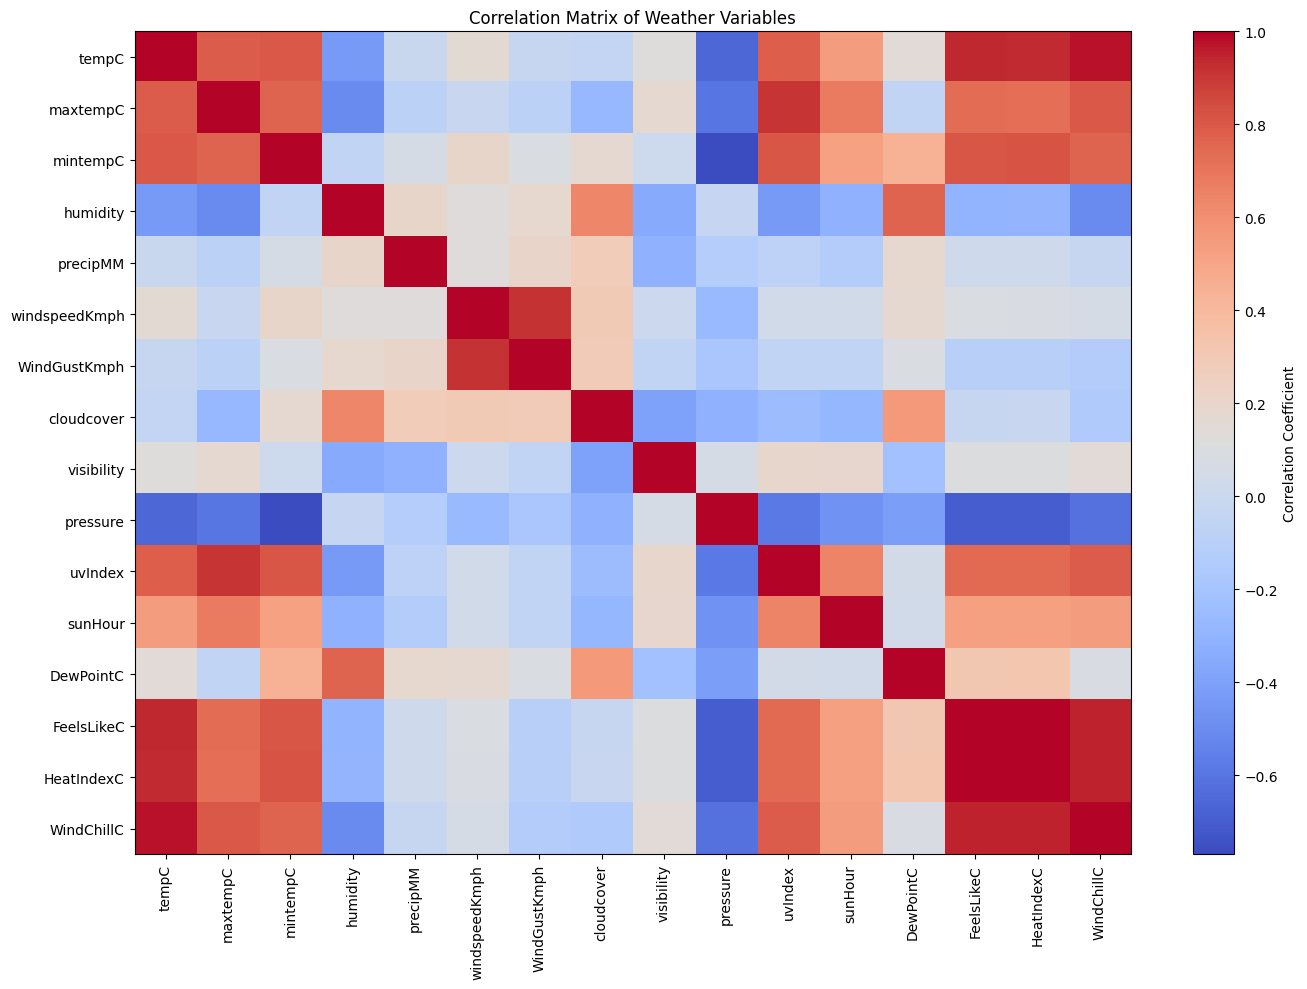


✓ Correlation analysis completed.


In [ ]:
# ==============================================================
# EDA 9 — CORRELATION ANALYSIS
# ==============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("                 CORRELATION ANALYSIS")
print("=" * 70)

# Select meaningful numerical weather variables
correlation_columns = [
    "tempC",
    "maxtempC",
    "mintempC",
    "humidity",
    "precipMM",
    "windspeedKmph",
    "WindGustKmph",
    "cloudcover",
    "visibility",
    "pressure",
    "uvIndex",
    "sunHour",
    "DewPointC",
    "FeelsLikeC",
    "HeatIndexC",
    "WindChillC"
]

correlation_matrix = weather_clean[correlation_columns].corr()

# Display matrix
display(correlation_matrix.round(2))

# --------------------------------------------------------------
# Find strongest relationships
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("STRONGEST CORRELATIONS")
print("-" * 70)

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

display(corr_pairs.head(15).round(3))

# --------------------------------------------------------------
# Correlation heatmap
# --------------------------------------------------------------

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(label="Correlation Coefficient")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Matrix of Weather Variables")

plt.tight_layout()
plt.show()

print("\n✓ Correlation analysis completed.")

In [ ]:
# ==============================================================
# EDA 10 — CORE WEATHER VARIABLE CORRELATIONS
# ==============================================================

core_columns = [
    "tempC",
    "maxtempC",
    "mintempC",
    "humidity",
    "precipMM",
    "windspeedKmph",
    "WindGustKmph",
    "cloudcover",
    "visibility",
    "pressure",
    "uvIndex",
    "sunHour",
    "DewPointC"
]

core_corr = weather_clean[core_columns].corr()

print("=" * 70)
print("           CORE WEATHER VARIABLE CORRELATIONS")
print("=" * 70)

display(core_corr.round(2))

print("\n" + "-" * 70)
print("STRONGEST CORE WEATHER RELATIONSHIPS")
print("-" * 70)

core_pairs = (
    core_corr
    .where(
        np.triu(
            np.ones(core_corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

display(core_pairs.head(12).round(3))

print("\n✓ Core correlation analysis completed.")

           CORE WEATHER VARIABLE CORRELATIONS


,tempC,maxtempC,mintempC,humidity,precipMM,windspeedKmph,WindGustKmph,cloudcover,visibility,pressure,uvIndex,sunHour,DewPointC
tempC,1.00,0.79,0.80,-0.44,-0.00,0.16,-0.03,-0.04,0.12,-0.66,0.78,0.54,0.14
maxtempC,0.79,1.00,0.76,-0.50,-0.09,-0.01,-0.08,-0.27,0.17,-0.59,0.91,0.68,-0.05
mintempC,0.80,0.76,1.00,-0.05,0.07,0.20,0.09,0.17,0.02,-0.77,0.81,0.52,0.44
humidity,-0.44,-0.50,-0.05,1.00,0.20,0.13,0.18,0.64,-0.35,-0.03,-0.43,-0.31,0.76
precipMM,-0.00,-0.09,0.07,0.20,1.00,0.13,0.21,0.27,-0.31,-0.12,-0.08,-0.13,0.18
windspeedKmph,0.16,-0.01,0.20,0.13,0.13,1.00,0.91,0.29,0.01,-0.26,0.03,0.04,0.17
WindGustKmph,-0.03,-0.08,0.09,0.18,0.21,0.91,1.00,0.28,-0.05,-0.18,-0.05,-0.05,0.09
cloudcover,-0.04,-0.27,0.17,0.64,0.27,0.29,0.28,1.00,-0.40,-0.31,-0.24,-0.28,0.55
visibility,0.12,0.17,0.02,-0.35,-0.31,0.01,-0.05,-0.40,1.00,0.06,0.20,0.19,-0.21
pressure,-0.66,-0.59,-0.77,-0.03,-0.12,-0.26,-0.18,-0.31,0.06,1.00,-0.58,-0.47,-0.42



----------------------------------------------------------------------
STRONGEST CORE WEATHER RELATIONSHIPS
----------------------------------------------------------------------


windspeedKmph  WindGustKmph    0.911
maxtempC       uvIndex         0.909
mintempC       uvIndex         0.810
tempC          mintempC        0.800
               maxtempC        0.786
               uvIndex         0.779
mintempC       pressure       -0.770
humidity       DewPointC       0.763
maxtempC       mintempC        0.760
               sunHour         0.676
tempC          pressure       -0.657
uvIndex        sunHour         0.641
dtype: float64


✓ Core correlation analysis completed.


In [ ]:
# ==============================================================
# EDA 11 — HOURLY WEATHER PATTERN ANALYSIS
# ==============================================================

print("=" * 70)
print("              HOURLY WEATHER PATTERN ANALYSIS")
print("=" * 70)

hourly_summary = (
    weather_clean.groupby("Hour")
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Avg_Humidity=("humidity", "mean"),
        Avg_Rainfall=("precipMM", "mean"),
        Rainy_Observations=("Rainy_Day", "sum"),
        Avg_Wind_Speed=("windspeedKmph", "mean"),
        Avg_Visibility=("visibility", "mean"),
        Avg_UV_Index=("uvIndex", "mean")
    )
    .reindex(range(24))
    .round(3)
)

display(hourly_summary)

print("\n" + "-" * 70)
print("HOURLY EXTREMES")
print("-" * 70)

print(
    f"Highest average temperature : "
    f"{hourly_summary['Avg_Temperature'].idxmax():02d}:00 "
    f"({hourly_summary['Avg_Temperature'].max():.2f} °C)"
)

print(
    f"Lowest average temperature  : "
    f"{hourly_summary['Avg_Temperature'].idxmin():02d}:00 "
    f"({hourly_summary['Avg_Temperature'].min():.2f} °C)"
)

print(
    f"Highest average humidity    : "
    f"{hourly_summary['Avg_Humidity'].idxmax():02d}:00 "
    f"({hourly_summary['Avg_Humidity'].max():.2f} %)"
)

print(
    f"Highest average rainfall    : "
    f"{hourly_summary['Avg_Rainfall'].idxmax():02d}:00 "
    f"({hourly_summary['Avg_Rainfall'].max():.3f} mm)"
)

print(
    f"Highest rainy observations  : "
    f"{hourly_summary['Rainy_Observations'].idxmax():02d}:00 "
    f"({hourly_summary['Rainy_Observations'].max():,.0f})"
)

print(
    f"Highest average wind speed  : "
    f"{hourly_summary['Avg_Wind_Speed'].idxmax():02d}:00 "
    f"({hourly_summary['Avg_Wind_Speed'].max():.2f} km/h)"
)

print(
    f"Highest average UV index    : "
    f"{hourly_summary['Avg_UV_Index'].idxmax():02d}:00 "
    f"({hourly_summary['Avg_UV_Index'].max():.2f})"
)

print("\n✓ Hourly EDA completed.")

              HOURLY WEATHER PATTERN ANALYSIS


,Avg_Temperature,Avg_Humidity,Avg_Rainfall,Rainy_Observations,Avg_Wind_Speed,Avg_Visibility,Avg_UV_Index
Hour,,,,,,,
0,23.104,60.470,0.143,4879,10.090,9.495,6.578
1,22.736,61.743,0.071,4169,9.681,9.449,6.578
2,22.370,63.023,0.018,703,9.276,9.431,6.578
3,22.002,64.312,0.024,714,8.872,9.383,6.578
4,23.076,61.200,0.012,628,9.507,9.525,6.578
5,24.157,58.095,0.093,4249,10.144,9.643,6.578
6,25.237,54.997,0.124,4529,10.777,9.784,6.578
7,26.895,50.494,0.062,3772,10.868,9.846,6.578
8,28.562,45.994,0.015,630,10.957,9.923,6.578



----------------------------------------------------------------------
HOURLY EXTREMES
----------------------------------------------------------------------
Highest average temperature : 12:00 (31.73 °C)
Lowest average temperature  : 03:00 (22.00 °C)
Highest average humidity    : 03:00 (64.31 %)
Highest average rainfall    : 18:00 (0.187 mm)
Highest rainy observations  : 18:00 (5,907)
Highest average wind speed  : 12:00 (12.41 km/h)
Highest average UV index    : 00:00 (6.58)

✓ Hourly EDA completed.


In [ ]:
# ==============================================================
# STATISTICAL ANALYSIS — WEATHER DATA
# ==============================================================

print("=" * 70)
print("                 STATISTICAL ANALYSIS")
print("=" * 70)

# --------------------------------------------------------------
# 1. DESCRIPTIVE STATISTICS — KEY WEATHER VARIABLES
# --------------------------------------------------------------

key_variables = [
    "tempC",
    "maxtempC",
    "mintempC",
    "humidity",
    "precipMM",
    "windspeedKmph",
    "WindGustKmph",
    "cloudcover",
    "visibility",
    "pressure",
    "uvIndex",
    "sunHour",
    "DewPointC"
]

print("\n" + "-" * 70)
print("1. DESCRIPTIVE STATISTICS")
print("-" * 70)

descriptive_stats = (
    weather_clean[key_variables]
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
    .round(3)
)

display(descriptive_stats)


# --------------------------------------------------------------
# 2. CITY-WISE TEMPERATURE VARIABILITY
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("2. CITY-WISE TEMPERATURE STATISTICS")
print("-" * 70)

city_temperature_stats = (
    weather_clean.groupby("City")["tempC"]
    .agg(
        Mean_Temperature="mean",
        Median_Temperature="median",
        Std_Deviation="std",
        Minimum_Temperature="min",
        Maximum_Temperature="max"
    )
    .sort_values("Mean_Temperature", ascending=False)
    .round(3)
)

display(city_temperature_stats)


# --------------------------------------------------------------
# 3. CITY-WISE RAINFALL STATISTICS
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("3. CITY-WISE RAINFALL STATISTICS")
print("-" * 70)

city_rainfall_stats = (
    weather_clean.groupby("City")["precipMM"]
    .agg(
        Mean_Rainfall="mean",
        Median_Rainfall="median",
        Std_Deviation="std",
        Maximum_Rainfall="max",
        Total_Rainfall="sum"
    )
    .sort_values("Total_Rainfall", ascending=False)
    .round(3)
)

display(city_rainfall_stats)


# --------------------------------------------------------------
# 4. EXTREME HEAT ANALYSIS
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("4. EXTREME HEAT STATISTICS")
print("-" * 70)

total_observations = len(weather_clean)
extreme_heat_observations = weather_clean["Extreme_Heat"].sum()

extreme_heat_percentage = (
    extreme_heat_observations / total_observations
) * 100

print(f"Total observations       : {total_observations:,}")
print(f"Extreme heat observations : {extreme_heat_observations:,}")
print(f"Extreme heat percentage   : {extreme_heat_percentage:.3f}%")
print(
    f"Maximum recorded temperature : "
    f"{weather_clean['tempC'].max():.0f} °C"
)


# --------------------------------------------------------------
# 5. RAINY OBSERVATION ANALYSIS
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("5. RAINFALL FREQUENCY")
print("-" * 70)

rainy_observations = weather_clean["Rainy_Day"].sum()

rainy_percentage = (
    rainy_observations / total_observations
) * 100

print(f"Total observations : {total_observations:,}")
print(f"Rainy observations : {rainy_observations:,}")
print(f"Rainy percentage   : {rainy_percentage:.3f}%")

print(
    f"Maximum rainfall in one observation : "
    f"{weather_clean['precipMM'].max():.1f} mm"
)


# --------------------------------------------------------------
# 6. SEASONAL TEMPERATURE VARIABILITY
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("6. SEASONAL TEMPERATURE STATISTICS")
print("-" * 70)

season_temperature_stats = (
    weather_clean.groupby("Season")["tempC"]
    .agg(
        Mean_Temperature="mean",
        Median_Temperature="median",
        Std_Deviation="std",
        Minimum_Temperature="min",
        Maximum_Temperature="max"
    )
    .round(3)
)

display(season_temperature_stats)


# --------------------------------------------------------------
# 7. CORRELATION SUMMARY
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("7. STRONGEST CORE CORRELATIONS")
print("-" * 70)

# Use the core correlation matrix calculated earlier
core_pairs = (
    core_corr
    .where(
        np.triu(
            np.ones(core_corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

correlation_summary = core_pairs.head(10).round(3)

display(correlation_summary)


# --------------------------------------------------------------
# 8. IMPORTANT DATASET CHARACTERISTICS
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("8. IMPORTANT DATASET CHARACTERISTICS")
print("-" * 70)

constant_columns = [
    col for col in weather_clean.columns
    if weather_clean[col].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

print(
    f"\nUV Index unique values : "
    f"{weather_clean['uvIndex'].nunique()}"
)

print(
    f"UV Index overall mean  : "
    f"{weather_clean['uvIndex'].mean():.3f}"
)

print(
    "\nNote: Hourly UV analysis should not be interpreted as a "
    "daily pattern because uvIndex has the same value across hours "
    "in the aggregated hourly output."
)

print("\n✓ Statistical analysis completed.")

                 STATISTICAL ANALYSIS

----------------------------------------------------------------------
1. DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
tempC,771456.0,26.463,6.725,0.0,22.0,26.0,31.0,51.0
maxtempC,771456.0,31.961,5.575,12.0,28.0,31.0,35.0,52.0
mintempC,771456.0,21.851,5.881,1.0,18.0,22.0,26.0,43.0
humidity,771456.0,51.597,24.475,2.0,31.0,51.0,72.0,100.0
precipMM,771456.0,0.068,0.400,0.0,0.0,0.0,0.0,30.6
windspeedKmph,771456.0,10.623,5.530,0.0,7.0,10.0,13.0,47.0
WindGustKmph,771456.0,15.170,7.872,0.0,9.0,14.0,20.0,85.0
cloudcover,771456.0,22.839,27.251,0.0,1.0,10.0,39.0,100.0
visibility,771456.0,9.714,1.432,0.0,10.0,10.0,10.0,20.0
pressure,771456.0,1008.523,5.838,986.0,1005.0,1009.0,1013.0,1026.0



----------------------------------------------------------------------
2. CITY-WISE TEMPERATURE STATISTICS
----------------------------------------------------------------------


,Mean_Temperature,Median_Temperature,Std_Deviation,Minimum_Temperature,Maximum_Temperature
City,,,,,
Nagpur,27.740,27.0,6.828,0,49
Bombay,27.528,27.0,2.889,0,38
Kanpur,27.430,28.0,8.460,0,50
Jaipur,26.810,28.0,8.221,0,48
Hyderabad,26.679,26.0,5.442,0,46
Delhi,26.672,28.0,8.917,0,51
Pune,24.868,24.0,5.031,0,42
Bengaluru,23.980,23.0,4.540,0,40



----------------------------------------------------------------------
3. CITY-WISE RAINFALL STATISTICS
----------------------------------------------------------------------


...


----------------------------------------------------------------------
4. EXTREME HEAT STATISTICS
----------------------------------------------------------------------
Total observations       : 771,456
Extreme heat observations : 1,303
Extreme heat percentage   : 0.169%
Maximum recorded temperature : 51 °C

----------------------------------------------------------------------
5. RAINFALL FREQUENCY
----------------------------------------------------------------------
Total observations : 771,456
Rainy observations : 68,354
Rainy percentage   : 8.860%
Maximum rainfall in one observation : 30.6 mm

----------------------------------------------------------------------
6. SEASONAL TEMPERATURE STATISTICS
----------------------------------------------------------------------


,Mean_Temperature,Median_Temperature,Std_Deviation,Minimum_Temperature,Maximum_Temperature
Season,,,,,
Monsoon,28.567,28.0,5.140,0,51
Post-Monsoon,24.628,25.0,4.495,10,38
Summer,30.670,31.0,6.206,7,49
Winter,20.573,21.0,5.779,1,40



----------------------------------------------------------------------
7. STRONGEST CORE CORRELATIONS
----------------------------------------------------------------------


windspeedKmph  WindGustKmph    0.911
maxtempC       uvIndex         0.909
mintempC       uvIndex         0.810
tempC          mintempC        0.800
               maxtempC        0.786
               uvIndex         0.779
mintempC       pressure       -0.770
humidity       DewPointC       0.763
maxtempC       mintempC        0.760
               sunHour         0.676
dtype: float64


----------------------------------------------------------------------
8. IMPORTANT DATASET CHARACTERISTICS
----------------------------------------------------------------------
Constant columns:
['totalSnow_cm']

UV Index unique values : 9
UV Index overall mean  : 6.578

Note: Hourly UV analysis should not be interpreted as a daily pattern because uvIndex has the same value across hours in the aggregated hourly output.

✓ Statistical analysis completed.


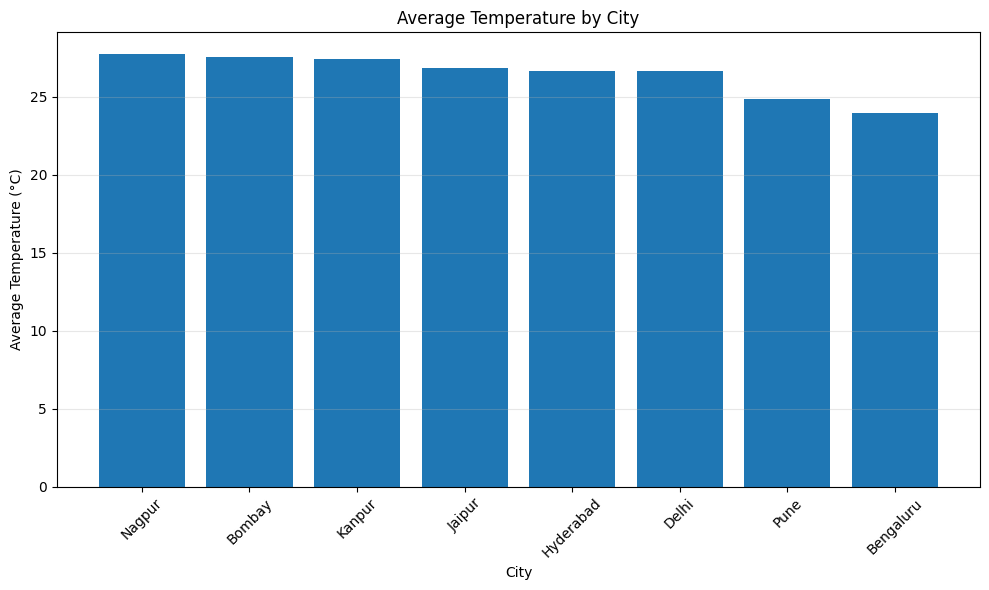

Average temperature by city:


,tempC
City,
Nagpur,27.74
Bombay,27.53
Kanpur,27.43
Jaipur,26.81
Hyderabad,26.68
Delhi,26.67
Pune,24.87
Bengaluru,23.98



✓ Visualization 1 completed.


In [ ]:
# ==============================================================
# VISUALIZATION 1 — AVERAGE TEMPERATURE BY CITY
# ==============================================================

import matplotlib.pyplot as plt

city_temp = (
    weather_clean.groupby("City")["tempC"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(city_temp.index, city_temp.values)

plt.title("Average Temperature by City")
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Average temperature by city:")
display(city_temp.round(2))

print("\n✓ Visualization 1 completed.")

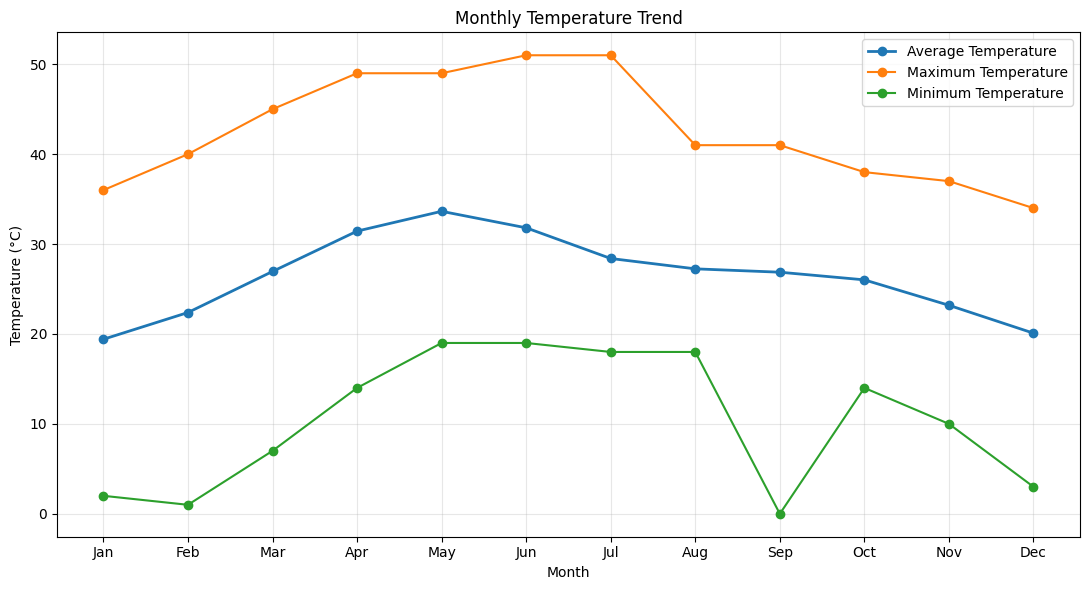

Monthly temperature statistics:


,Avg_Temperature,Max_Temperature,Min_Temperature
Month,,,
1,19.41,36,2
2,22.39,40,1
3,26.95,45,7
4,31.44,49,14
5,33.64,49,19
6,31.81,51,19
7,28.40,51,18
8,27.25,41,18
9,26.87,41,0



✓ Visualization 2 completed.


In [ ]:
# ==============================================================
# VISUALIZATION 2 — MONTHLY TEMPERATURE TREND
# ==============================================================

import matplotlib.pyplot as plt

monthly_temp = (
    weather_clean.groupby("Month")
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Max_Temperature=("tempC", "max"),
        Min_Temperature=("tempC", "min")
    )
    .reindex(range(1, 13))
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(11, 6))

plt.plot(
    month_labels,
    monthly_temp["Avg_Temperature"],
    marker="o",
    linewidth=2,
    label="Average Temperature"
)

plt.plot(
    month_labels,
    monthly_temp["Max_Temperature"],
    marker="o",
    linewidth=1.5,
    label="Maximum Temperature"
)

plt.plot(
    month_labels,
    monthly_temp["Min_Temperature"],
    marker="o",
    linewidth=1.5,
    label="Minimum Temperature"
)

plt.title("Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Monthly temperature statistics:")
display(monthly_temp.round(2))

print("\n✓ Visualization 2 completed.")

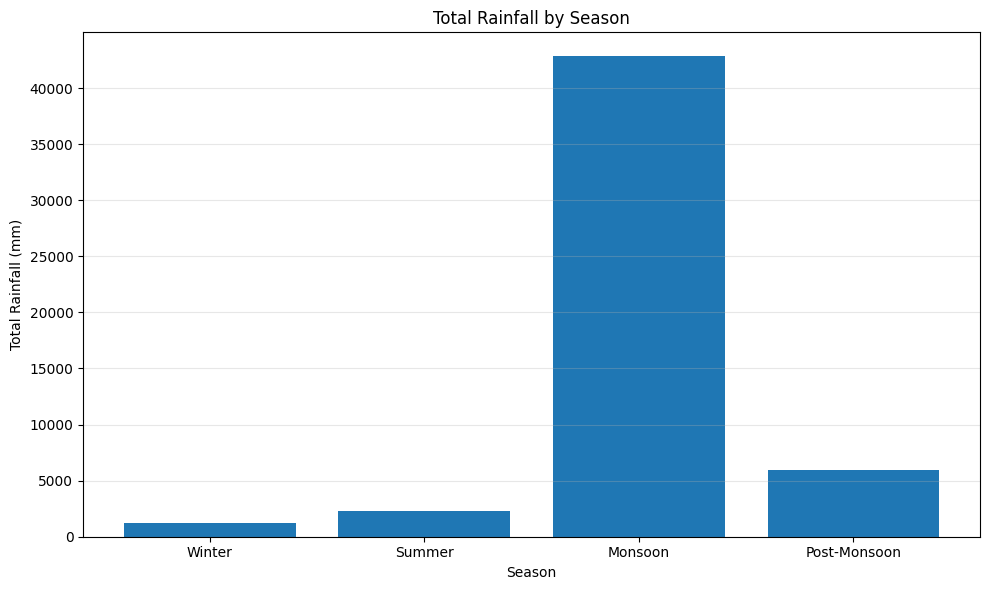

Seasonal rainfall:


,precipMM
Season,
Winter,1245.8
Summer,2306.6
Monsoon,42827.0
Post-Monsoon,5967.1



✓ Visualization 3 completed.


In [ ]:
# ==============================================================
# VISUALIZATION 3 — SEASONAL RAINFALL COMPARISON
# ==============================================================

import matplotlib.pyplot as plt

season_order = [
    "Winter",
    "Summer",
    "Monsoon",
    "Post-Monsoon"
]

season_rainfall = (
    weather_clean.groupby("Season")["precipMM"]
    .sum()
    .reindex(season_order)
)

plt.figure(figsize=(10, 6))

plt.bar(
    season_rainfall.index,
    season_rainfall.values
)

plt.title("Total Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Seasonal rainfall:")
display(season_rainfall.round(2))

print("\n✓ Visualization 3 completed.")

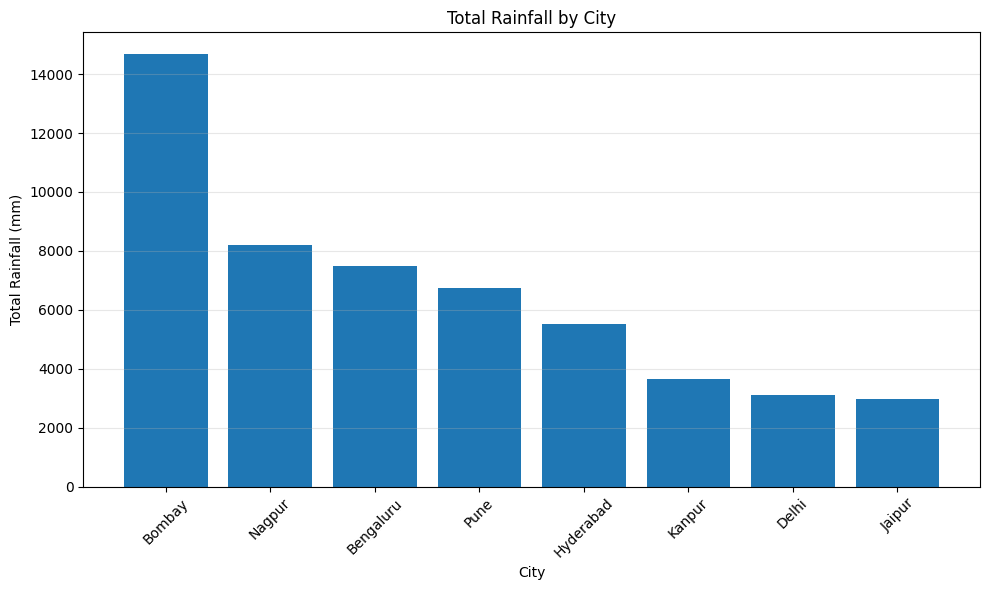

Total rainfall by city:


,precipMM
City,
Bombay,14684.5
Nagpur,8213.5
Bengaluru,7494.6
Pune,6747.5
Hyderabad,5501.9
Kanpur,3640.9
Delhi,3092.8
Jaipur,2970.8



✓ Visualization 4 completed.


In [ ]:
# ==============================================================
# VISUALIZATION 4 — TOTAL RAINFALL BY CITY
# ==============================================================

import matplotlib.pyplot as plt

city_rainfall = (
    weather_clean.groupby("City")["precipMM"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    city_rainfall.index,
    city_rainfall.values
)

plt.title("Total Rainfall by City")
plt.xlabel("City")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Total rainfall by city:")
display(city_rainfall.round(2))

print("\n✓ Visualization 4 completed.")

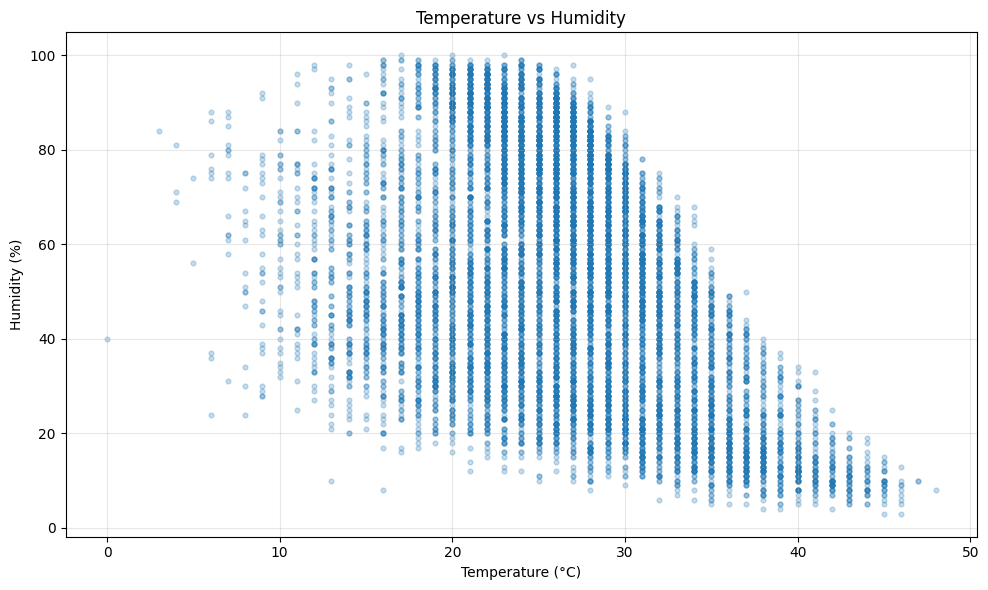

Pearson correlation coefficient: -0.436

✓ Visualization 5 completed.


In [ ]:
# ==============================================================
# VISUALIZATION 5 — TEMPERATURE VS HUMIDITY
# ==============================================================

import matplotlib.pyplot as plt

# Sample observations only for visualization
# The statistical correlation was calculated using the full dataset.
plot_data = weather_clean[
    ["tempC", "humidity"]
].sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["tempC"],
    plot_data["humidity"],
    alpha=0.25,
    s=12
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

correlation = weather_clean["tempC"].corr(
    weather_clean["humidity"]
)

print(f"Pearson correlation coefficient: {correlation:.3f}")

print("\n✓ Visualization 5 completed.")

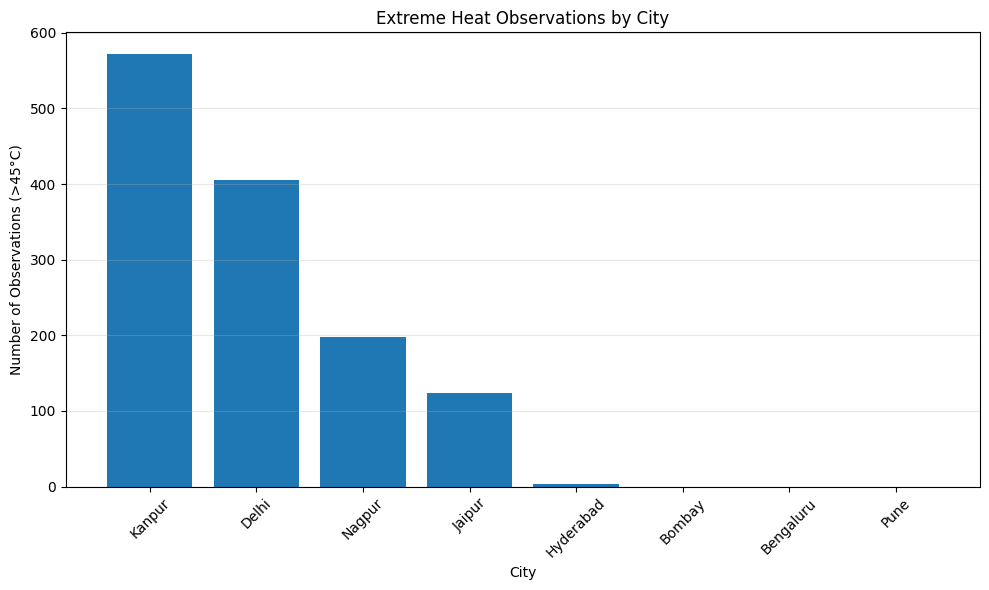

Extreme heat observations by city:


,Extreme_Heat
City,
Kanpur,572
Delhi,406
Nagpur,198
Jaipur,124
Hyderabad,3
Bombay,0
Bengaluru,0
Pune,0



✓ Visualization 6 completed.


In [ ]:
# ==============================================================
# VISUALIZATION 6 — EXTREME HEAT BY CITY
# ==============================================================

import matplotlib.pyplot as plt

extreme_heat_city = (
    weather_clean.groupby("City")["Extreme_Heat"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    extreme_heat_city.index,
    extreme_heat_city.values
)

plt.title("Extreme Heat Observations by City")
plt.xlabel("City")
plt.ylabel("Number of Observations (>45°C)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Extreme heat observations by city:")
display(extreme_heat_city)

print("\n✓ Visualization 6 completed.")

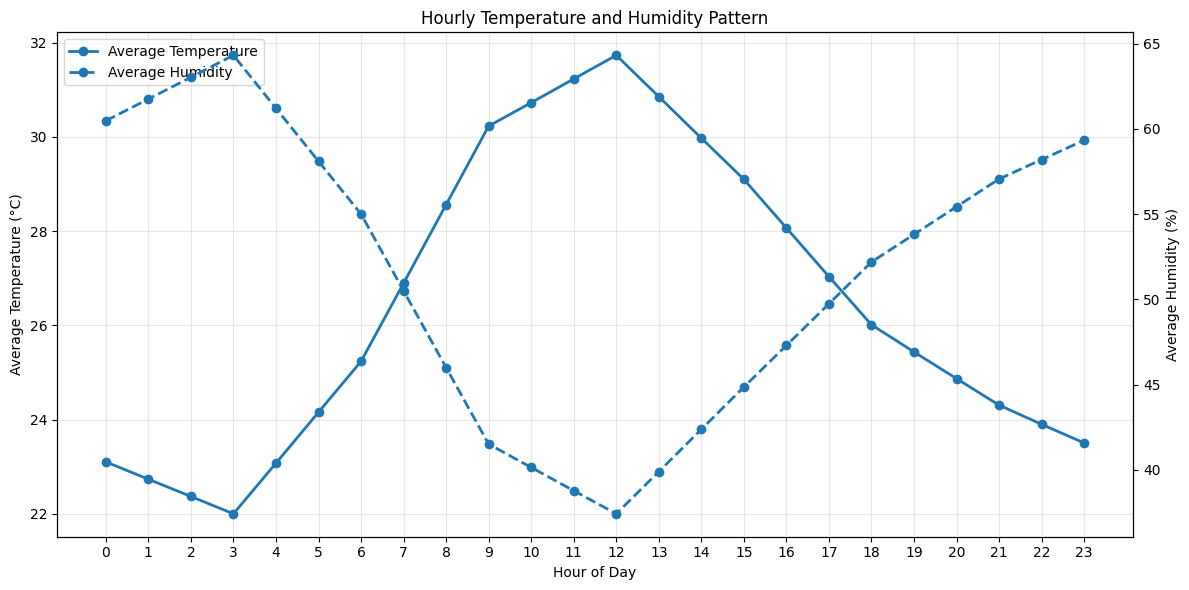

Hourly temperature and humidity:


,Avg_Temperature,Avg_Humidity
Hour,,
0,23.10,60.47
1,22.74,61.74
2,22.37,63.02
3,22.00,64.31
4,23.08,61.20
5,24.16,58.09
6,25.24,55.00
7,26.89,50.49
8,28.56,45.99



✓ Final Visualization 7 completed.


In [ ]:
# ==============================================================
# VISUALIZATION 7 — FINAL VERSION
# HOURLY TEMPERATURE & HUMIDITY PATTERN
# ==============================================================

import matplotlib.pyplot as plt

hourly_pattern = (
    weather_clean.groupby("Hour")
    .agg(
        Avg_Temperature=("tempC", "mean"),
        Avg_Humidity=("humidity", "mean")
    )
    .reindex(range(24))
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature
line1 = ax1.plot(
    hourly_pattern.index,
    hourly_pattern["Avg_Temperature"],
    marker="o",
    linewidth=2,
    linestyle="-",
    label="Average Temperature"
)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Temperature (°C)")
ax1.set_xticks(range(24))
ax1.grid(alpha=0.3)

# Humidity
ax2 = ax1.twinx()

line2 = ax2.plot(
    hourly_pattern.index,
    hourly_pattern["Avg_Humidity"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Average Humidity"
)

ax2.set_ylabel("Average Humidity (%)")

# Combined legend
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="upper left"
)

plt.title("Hourly Temperature and Humidity Pattern")
plt.tight_layout()
plt.show()

print("Hourly temperature and humidity:")
display(hourly_pattern.round(2))

print("\n✓ Final Visualization 7 completed.")

In [ ]:
# ==============================================================
# POWER BI PREPARATION — FINAL DATASET
# ==============================================================

print("=" * 70)
print("              POWER BI DATA PREPARATION")
print("=" * 70)

# --------------------------------------------------------------
# 1. CREATE POWER BI DATASET
# --------------------------------------------------------------

powerbi_df = weather_clean.copy()

# Ensure datetime is properly formatted
powerbi_df["date_time"] = pd.to_datetime(
    powerbi_df["date_time"],
    errors="coerce"
)

# Remove constant column
if "totalSnow_cm" in powerbi_df.columns:
    powerbi_df = powerbi_df.drop(columns=["totalSnow_cm"])

# --------------------------------------------------------------
# 2. SORT DATA
# --------------------------------------------------------------

powerbi_df = powerbi_df.sort_values(
    ["City", "date_time"]
).reset_index(drop=True)


# --------------------------------------------------------------
# 3. FINAL VALIDATION
# --------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL POWER BI DATASET VALIDATION")
print("-" * 70)

print(f"Rows              : {len(powerbi_df):,}")
print(f"Columns           : {len(powerbi_df.columns)}")
print(f"Missing cells     : {powerbi_df.isna().sum().sum():,}")
print(f"Duplicate rows    : {powerbi_df.duplicated().sum():,}")
print(f"Invalid dates     : {powerbi_df['date_time'].isna().sum():,}")
print(f"Cities            : {powerbi_df['City'].nunique()}")
print(
    f"Start date        : "
    f"{powerbi_df['date_time'].min()}"
)
print(
    f"End date          : "
    f"{powerbi_df['date_time'].max()}"
)

print("\nColumns:")
for i, column in enumerate(powerbi_df.columns, 1):
    print(f"{i:02d}. {column}")


# --------------------------------------------------------------
# 4. VERIFY ENGINEERED FEATURES
# --------------------------------------------------------------

required_features = [
    "Year",
    "Month",
    "Month_Name",
    "Day",
    "Hour",
    "Day_of_Week",
    "Season",
    "Temperature_Range",
    "Rainfall_Category",
    "Humidity_Category",
    "Wind_Speed_Category",
    "Rainy_Day",
    "Extreme_Heat"
]

missing_features = [
    col for col in required_features
    if col not in powerbi_df.columns
]

print("\n" + "-" * 70)
print("ENGINEERED FEATURE CHECK")
print("-" * 70)

if not missing_features:
    print("All required engineered features are present.")
else:
    print("Missing features:")
    print(missing_features)


# --------------------------------------------------------------
# 5. SAVE FOR POWER BI
# --------------------------------------------------------------

output_path = (
    "/content/drive/MyDrive/"
    "Weather_Data_Analysis/"
    "Weather_Data_PowerBI.csv"
)

powerbi_df.to_csv(
    output_path,
    index=False
)

print("\n" + "-" * 70)
print("EXPORT")
print("-" * 70)

print(f"Power BI file saved to:")
print(output_path)

print("\n✓ Power BI preparation completed.")

              POWER BI DATA PREPARATION

----------------------------------------------------------------------
FINAL POWER BI DATASET VALIDATION
----------------------------------------------------------------------
Rows              : 771,456
Columns           : 38
Missing cells     : 0
Duplicate rows    : 0
Invalid dates     : 0
Cities            : 8
Start date        : 2009-01-01 00:00:00
End date          : 2020-01-01 23:00:00

Columns:
01. date_time
02. maxtempC
03. mintempC
04. sunHour
05. uvIndex
06. uvIndex.1
07. moon_illumination
08. moonrise
09. moonset
10. sunrise
11. sunset
12. DewPointC
13. FeelsLikeC
14. HeatIndexC
15. WindChillC
16. WindGustKmph
17. cloudcover
18. humidity
19. precipMM
20. pressure
21. tempC
22. visibility
23. winddirDegree
24. windspeedKmph
25. City
26. Year
27. Month
28. Month_Name
29. Day
30. Hour
31. Day_of_Week
32. Season
33. Temperature_Range
34. Rainfall_Category
35. Humidity_Category
36. Wind_Speed_Category
37. Rainy_Day
38. Extreme_Heat

------